In [ ]:
#!pip install  pymc arviz catboost shap dowhy econml  dask[dataframe] #pymc causalimpact

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 8.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 8.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pytensor to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 12.3 MB/s eta 0:00:00
INFO: pip is still looking at multiple versions of pytensor to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 12.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 13.3 MB/s eta 0:00:00
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa

In [ ]:
!pip install catboost econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 11.4 MB/s eta 0:00:00


In [ ]:
!pip install dask[dataframe]

INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.2/243.2 kB 1.4 MB/s eta 0:00:00


In [ ]:
import os
import re
from tqdm import tqdm
import numpy as np
from collections import defaultdict
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
import sys
import pandas as pd
import gcsfs
import pyarrow
import catboost
from catboost import CatBoostClassifier
import pyarrow.dataset as ds
import gcsfs
import gc
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from google.cloud import bigquery

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
import statsmodels.api as sm
#from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

from econml.dml import CausalForestDML
#from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import GradientBoostingRegressor
from econml.panel.dml import DynamicDML
import itertools
from typing import List, Tuple, Dict

# =========================================================
# =============== USER CONFIGURATION ======================
# =========================================================

N_BOOT = 250                # Number of bootstrap samples
RANDOM_STATE = 42            # Random seed




In [ ]:
# Initialize the BigQuery client
client = bigquery.Client()

# Define the table reference, which was used in the previous cell
#table_ref = "expanded-nebula-754.sandbox_devanh.pnaPhase2better"
#table_ref = "expanded-nebula-754.sandbox_devanh.pnaPhase2better"
table_ref = "expanded-nebula-754.sandbox_devanh.pnaPhase2sampled"
# Use the BigQuery client to download the table directly into a DataFrame.
# This is more reliable than exporting to GCS and then reading from GCS.
print("Loading data directly from BigQuery...")
df = client.query(f"SELECT * FROM `{table_ref}`").to_dataframe()

print("Successfully loaded data into a DataFrame.")
print(len(df))

Loading data directly from BigQuery...
Successfully loaded data into a DataFrame.
1856344


In [ ]:

import pyarrow as pa
import pyarrow.dataset as ds
from pyarrow.fs import GcsFileSystem

gcs = GcsFileSystem()

table = pa.Table.from_pandas(df, preserve_index=False)

ds.write_dataset(
    data=table,
    base_dir="cdow/causal_analysis/raw_table_new",
    format="parquet",
    filesystem=gcs,
    max_rows_per_file=5_000_000,
    max_rows_per_group=500_000,
    basename_template="caus-{i}.parquet",
)

In [ ]:
import pyarrow as pa
import pyarrow.dataset as ds
from pyarrow.fs import GcsFileSystem
gcs = GcsFileSystem()
BASE_DIR="cdow/causal_analysis/raw_table_new"
dataset = ds.dataset(BASE_DIR, format="parquet", filesystem=gcs)  # auto-detects partitions
# Read everything into pandas (requires memory)
table = dataset.to_table()          # optionally columns=["c1","c2"]
df = table.to_pandas()
import gc
gc.collect()

0

In [ ]:
def filter_rare_categories(df, categorical_cols, threshold):
    """
    Removes rows from the DataFrame where any specified categorical column
    has a category whose relative frequency is below the threshold.

    Parameters:
    - df (pd.DataFrame): Input DataFrame
    - categorical_cols (list): List of column names (categorical)
    - threshold (float): Minimum percentage threshold (0.0 to 1.0)

    Returns:
    - pd.DataFrame: Filtered DataFrame
    """
    df_filtered = df.copy()

    for col in categorical_cols:
        # Calculate frequency and percentage
        #print('------------------')
        #print(col)
        freq = df_filtered[col].value_counts(normalize=True)
        #print(freq)
        valid_categories = freq[freq >= threshold].index
        print(valid_categories)



        # Filter rows where the category is common enough
        df_filtered = df_filtered[df_filtered[col].isin(valid_categories)]
        df.reset_index(drop=True, inplace=True)

    return df_filtered


In [ ]:
import gc
print(len(df))
#cat_col_trim = ['channel'	,'industry' , 'sub_region' ,'customer_size_bucket','product_type','product_business_division','product_business_division_expanded','product_business_unit']
cat_col_trim = ['product_business_division','product_business_division_expanded','product_business_unit']
#'warehouse','product_brand'#sub_region#sub_region
#product_business_division, product_business_division_expanded, product_business_unit

#persona
#product_type
df = filter_rare_categories(df, cat_col_trim[-3:], 0.01)
df.reset_index(drop=True, inplace=True)
gc.collect()
print(len(df))

1856344
Index(['b - Discovery Solutions', 'a - Advanced Solutions',
       'c - Process Solutions'],
      dtype='object', name='product_business_division')
Index(['c - LR2 Chemistry', 'a - Advanced Solutions', 'd - LR4 Biology',
       'b - Process Solutions'],
      dtype='object', name='product_business_division_expanded')
Index(['LR2 Chemistry', 'LA4 Diagnostics & Regulated Materials', 'LR4 Biology',
       'LA2 Biomonitoring', 'LP3 Upstream & Process Materials',
       'LA1 Lab Water Solutions', 'LP2 Downstream'],
      dtype='object', name='product_business_unit')
1843040


In [ ]:
pd.set_option('display.max_columns', None)

# Prevent column width truncation
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
from IPython.display import display
display(df.loc[0:1, :])

,ga_session_id,participant_id,event_date,event_timstamp_standard,event_timestamp_posix,country,sub_region,industry,industry_high_level,channel,customer_size_total_revenue_euros,customer_size_bucket,persona,product_brand,product_variant,lead_time,lead_time_buckets,data_driven_lead_time_buckets,warehouse,list_price_per_item_euros,discounted_price_per_item_euros,price_per_item_bucket,product_popularity_by_pna_views,product_popularity_by_revenue,discount_percentage,discount_percentage_bucket,data_driven_discount_percentage_bucket,product_type,product_business_division,product_business_division_expanded,product_business_unit,viewed_sku_28_to_22_days_ago,viewed_sku_21_to_15_days_ago,viewed_sku_14_to_8_days_ago,viewed_sku_7_days_to_1_second_ago,views_sku_1_second_to_7_days_in_the_future,views_sku_8_days_to_14_days_in_the_future,views_sku_15_days_to_21_days_in_the_future,views_sku_22_days_to_28_days_in_the_future,viewed_material_28_to_22_days_ago,viewed_material_21_to_15_days_ago,viewed_material_14_to_8_days_ago,viewed_material_7_days_to_1_second_ago,views_material_1_second_to_7_days_in_the_future,views_material_8_days_to_14_days_in_the_future,views_material_15_days_to_21_days_in_the_future,views_material_22_days_to_28_days_in_the_future,sku_added_to_cart_28_to_22_days_ago,sku_added_to_cart_21_to_15_days_ago,sku_added_to_cart_14_to_8_days_ago,sku_added_to_cart_7_days_to_1_second_ago,sku_will_be_added_to_cart_1_second_to_7_days_in_the_future,sku_will_be_added_to_cart_8_days_to_14_days_in_the_future,sku_will_be_added_to_cart_15_days_to_21_days_in_the_future,sku_will_be_added_to_cart_22_days_to_28_days_in_the_future,purchased_sku_order_lines_28_to_22_days_ago,purchased_sku_order_lines_21_to_15_days_ago,purchased_sku_order_lines_14_to_8_days_ago,purchased_sku_order_lines_7_days_to_1_second_ago,purchases_sku_order_lines_1_second_to_7_days_in_the_future,purchases_sku_order_lines_8_days_to_14_days_in_the_future,purchases_sku_order_lines_15_days_to_21_days_in_the_future,purchases_sku_order_lines_22_days_to_28_days_in_the_future,purchased_sku_quantity_28_to_22_days_ago,purchased_sku_quantity_21_to_15_days_ago,purchased_sku_quantity_14_to_8_days_ago,purchased_sku_quantity_7_days_to_1_second_ago,purchases_sku_quantity_1_second_to_7_days_in_the_future,purchases_sku_quantity_8_days_to_14_days_in_the_future,purchases_sku_quantity_15_days_to_21_days_in_the_future,purchases_sku_quantity_22_days_to_28_days_in_the_future,purchased_sku_revenue_euro_28_to_22_days_ago,purchased_sku_revenue_euro_21_to_15_days_ago,purchased_sku_revenue_euro_14_to_8_days_ago,purchased_sku_revenue_euro_7_days_to_1_second_ago,purchases_sku_revenue_euro_1_second_to_7_days_in_the_future,purchases_sku_revenue_euro_8_days_to_14_days_in_the_future,purchases_sku_revenue_euro_15_days_to_21_days_in_the_future,purchases_sku_revenue_euro_22_days_to_28_days_in_the_future,material_added_to_cart_28_to_22_days_ago,material_added_to_cart_21_to_15_days_ago,material_added_to_cart_14_to_8_days_ago,material_added_to_cart_7_days_to_1_second_ago,material_will_be_added_to_cart_1_second_to_7_days_in_the_future,material_will_be_added_to_cart_8_days_to_14_days_in_the_future,material_will_be_added_to_cart_15_days_to_21_days_in_the_future,material_will_be_added_to_cart_22_days_to_28_days_in_the_future,purchased_material_order_lines_28_to_22_days_ago,purchased_material_order_lines_21_to_15_days_ago,purchased_material_order_lines_14_to_8_days_ago,purchased_material_order_lines_7_days_to_1_second_ago,purchases_material_order_lines_1_second_to_7_days_in_the_future,purchases_material_order_lines_8_days_to_14_days_in_the_future,purchases_material_order_lines_15_days_to_21_days_in_the_future,purchases_material_order_lines_22_days_to_28_days_in_the_future,purchased_material_quantity_28_to_22_days_ago,purchased_material_quantity_21_to_15_days_ago,purchased_material_quantity_14_to_8_days_ago,purchased_material_quantity_7_days_to_1_second_ago,purchases_material_quantity_1_second_to_7_days_in_the_future,purchases_m

In [ ]:
df_copy = df.copy()
df_copy['viewed_sku'] =  df_copy['viewed_sku_7_days_to_1_second_ago'] + df_copy['viewed_sku_21_to_15_days_ago']	+ df_copy['viewed_sku_14_to_8_days_ago']#df_copy['purchased_sku_order_lines_7_days_to_1_second_ago']	+
df_copy['purchased_sku']  =  df_copy['purchases_sku_order_lines_1_second_to_7_days_in_the_future'] +	df_copy['purchases_sku_order_lines_8_days_to_14_days_in_the_future']# + \
	  #df_copy['purchases_sku_order_lines_15_days_to_21_days_in_the_future']# +df_copy['purchased_sku_order_lines_21_to_15_days_ago'] +	df_copy['purchased_sku_order_lines_14_to_8_days_ago']

df_copy['event_timestamp'] = pd.to_datetime(df_copy['event_timestamp_posix'],unit='s')
df_copy['month'] = df_copy['event_timestamp'].dt.month
df_copy['day'] =  df_copy['event_timestamp'].dt.day
df_copy['hour'] = df_copy['event_timestamp'].dt.hour
df_copy['minute'] = df_copy['event_timestamp'].dt.minute


pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
from IPython.display import display
display(df_copy.loc[0:1, :])#['viewed_sku','purchased_sku','month','day','hour']])



viewed_counts = df_copy['viewed_sku'].value_counts().sort_index()

# Frequency of integers in 'sku_purchased'
purchased_counts = df_copy['purchased_sku'].value_counts().sort_index()
#del df
#import gc
gc.collect()

df_copy['customer_size_total_revenue_euros'] = pd.to_numeric(
    df_copy['customer_size_total_revenue_euros'], errors='coerce'
)

# Build mask for rows to remove
mask_remove = (
    (df_copy['industry'].eq('unavailable'))# & df_copy['customer_size_total_revenue_euros'].eq(0.0))
    | df_copy['industry'].isna()
    | df_copy['customer_size_total_revenue_euros'].isna()
)

# Drop those rows in place
df_copy = df_copy.loc[~mask_remove].copy()
# Reset the index to ensure it's contiguous after filtering
df_copy.reset_index(drop=True, inplace=True)

# Optional: print summary
print(f"Removed {mask_remove.sum()} rows. Remaining: {len(df_copy)}")
gc.collect()

,ga_session_id,participant_id,event_date,event_timstamp_standard,event_timestamp_posix,country,sub_region,industry,industry_high_level,channel,customer_size_total_revenue_euros,customer_size_bucket,persona,product_brand,product_variant,lead_time,lead_time_buckets,data_driven_lead_time_buckets,warehouse,list_price_per_item_euros,discounted_price_per_item_euros,price_per_item_bucket,product_popularity_by_pna_views,product_popularity_by_revenue,discount_percentage,discount_percentage_bucket,data_driven_discount_percentage_bucket,product_type,product_business_division,product_business_division_expanded,product_business_unit,viewed_sku_28_to_22_days_ago,viewed_sku_21_to_15_days_ago,viewed_sku_14_to_8_days_ago,viewed_sku_7_days_to_1_second_ago,views_sku_1_second_to_7_days_in_the_future,views_sku_8_days_to_14_days_in_the_future,views_sku_15_days_to_21_days_in_the_future,views_sku_22_days_to_28_days_in_the_future,viewed_material_28_to_22_days_ago,viewed_material_21_to_15_days_ago,viewed_material_14_to_8_days_ago,viewed_material_7_days_to_1_second_ago,views_material_1_second_to_7_days_in_the_future,views_material_8_days_to_14_days_in_the_future,views_material_15_days_to_21_days_in_the_future,views_material_22_days_to_28_days_in_the_future,sku_added_to_cart_28_to_22_days_ago,sku_added_to_cart_21_to_15_days_ago,sku_added_to_cart_14_to_8_days_ago,sku_added_to_cart_7_days_to_1_second_ago,sku_will_be_added_to_cart_1_second_to_7_days_in_the_future,sku_will_be_added_to_cart_8_days_to_14_days_in_the_future,sku_will_be_added_to_cart_15_days_to_21_days_in_the_future,sku_will_be_added_to_cart_22_days_to_28_days_in_the_future,purchased_sku_order_lines_28_to_22_days_ago,purchased_sku_order_lines_21_to_15_days_ago,purchased_sku_order_lines_14_to_8_days_ago,purchased_sku_order_lines_7_days_to_1_second_ago,purchases_sku_order_lines_1_second_to_7_days_in_the_future,purchases_sku_order_lines_8_days_to_14_days_in_the_future,purchases_sku_order_lines_15_days_to_21_days_in_the_future,purchases_sku_order_lines_22_days_to_28_days_in_the_future,purchased_sku_quantity_28_to_22_days_ago,purchased_sku_quantity_21_to_15_days_ago,purchased_sku_quantity_14_to_8_days_ago,purchased_sku_quantity_7_days_to_1_second_ago,purchases_sku_quantity_1_second_to_7_days_in_the_future,purchases_sku_quantity_8_days_to_14_days_in_the_future,purchases_sku_quantity_15_days_to_21_days_in_the_future,purchases_sku_quantity_22_days_to_28_days_in_the_future,purchased_sku_revenue_euro_28_to_22_days_ago,purchased_sku_revenue_euro_21_to_15_days_ago,purchased_sku_revenue_euro_14_to_8_days_ago,purchased_sku_revenue_euro_7_days_to_1_second_ago,purchases_sku_revenue_euro_1_second_to_7_days_in_the_future,purchases_sku_revenue_euro_8_days_to_14_days_in_the_future,purchases_sku_revenue_euro_15_days_to_21_days_in_the_future,purchases_sku_revenue_euro_22_days_to_28_days_in_the_future,material_added_to_cart_28_to_22_days_ago,material_added_to_cart_21_to_15_days_ago,material_added_to_cart_14_to_8_days_ago,material_added_to_cart_7_days_to_1_second_ago,material_will_be_added_to_cart_1_second_to_7_days_in_the_future,material_will_be_added_to_cart_8_days_to_14_days_in_the_future,material_will_be_added_to_cart_15_days_to_21_days_in_the_future,material_will_be_added_to_cart_22_days_to_28_days_in_the_future,purchased_material_order_lines_28_to_22_days_ago,purchased_material_order_lines_21_to_15_days_ago,purchased_material_order_lines_14_to_8_days_ago,purchased_material_order_lines_7_days_to_1_second_ago,purchases_material_order_lines_1_second_to_7_days_in_the_future,purchases_material_order_lines_8_days_to_14_days_in_the_future,purchases_material_order_lines_15_days_to_21_days_in_the_future,purchases_material_order_lines_22_days_to_28_days_in_the_future,purchased_material_quantity_28_to_22_days_ago,purchased_material_quantity_21_to_15_days_ago,purchased_material_quantity_14_to_8_days_ago,purchased_material_quantity_7_days_to_1_second_ago,purchases_material_quantity_1_second_to_7_days_in_the_future,purchases_m

Removed 444512 rows. Remaining: 1398528


18

In [ ]:
cols_to_drop = ['viewed_material_28_to_22_days_ago','viewed_material_21_to_15_days_ago','viewed_material_14_to_8_days_ago','viewed_material_7_days_to_1_second_ago',\
                'views_material_1_second_to_7_days_in_the_future','views_material_8_days_to_14_days_in_the_future','views_material_15_days_to_21_days_in_the_future',\
                'views_material_22_days_to_28_days_in_the_future','sku_added_to_cart_28_to_22_days_ago','sku_added_to_cart_21_to_15_days_ago','sku_added_to_cart_14_to_8_days_ago',\
                'sku_added_to_cart_7_days_to_1_second_ago','sku_will_be_added_to_cart_1_second_to_7_days_in_the_future','sku_will_be_added_to_cart_8_days_to_14_days_in_the_future',\
                'sku_will_be_added_to_cart_15_days_to_21_days_in_the_future','sku_will_be_added_to_cart_22_days_to_28_days_in_the_future',\
                'purchased_material_order_lines_21_to_15_days_ago','purchased_material_order_lines_14_to_8_days_ago','purchased_material_order_lines_7_days_to_1_second_ago',\
                'purchases_material_order_lines_1_second_to_7_days_in_the_future','purchases_material_order_lines_8_days_to_14_days_in_the_future','purchases_material_order_lines_15_days_to_21_days_in_the_future',\
                'purchases_material_order_lines_22_days_to_28_days_in_the_future','purchased_material_quantity_28_to_22_days_ago','purchased_material_quantity_21_to_15_days_ago','purchased_material_quantity_14_to_8_days_ago',\
                'purchased_material_quantity_7_days_to_1_second_ago','purchases_material_quantity_1_second_to_7_days_in_the_future','purchases_material_quantity_8_days_to_14_days_in_the_future',\
                'purchases_material_quantity_15_days_to_21_days_in_the_future','purchases_material_quantity_22_days_to_28_days_in_the_future','purchased_material_revenue_euro_28_to_22_days_ago',\
                'purchased_material_revenue_euro_21_to_15_days_ago','purchased_material_revenue_euro_14_to_8_days_ago','purchased_material_revenue_euro_7_days_to_1_second_ago',\
                'purchases_material_revenue_euro_1_second_to_7_days_in_the_future','purchases_material_revenue_euro_8_days_to_14_days_in_the_future','purchases_material_revenue_euro_15_days_to_21_days_in_the_future',\
                'purchases_material_revenue_euro_22_days_to_28_days_in_the_future']

# Drop columns in place
df_copy.drop(columns=cols_to_drop, inplace=True)
del df
# Force garbage collection to free memory
import gc
gc.collect()


del cols_to_drop
gc.collect()

0

In [ ]:
# Column names
LP = 'list_price_per_item_euros'
DP = 'discounted_price_per_item_euros'
DC = 'discount_percentage'

cols = [LP, DP, DC]

# If df might be a view of another DataFrame, uncomment to avoid SettingWithCopyWarning
# df = df.copy()

# 0) Ensure numeric
df_copy[cols] = df_copy[cols].apply(pd.to_numeric, errors='coerce')

# 1) If any of the three is NaN, set all three to 0.0 (your original rule)
mask_nan = df_copy[cols].isna().any(axis=1)
df_copy.loc[mask_nan, cols] = 0.0

# 2) Fix inversions: list < discounted  -> set discounted = list, discount% = 0.0
mask_inverted = df_copy[LP] < df_copy[DP]
# set discounted to list for those rows
df_copy.loc[mask_inverted, DP] = df_copy.loc[mask_inverted, LP].to_numpy()
# set discount_percentage to 0.0 for those rows
df_copy.loc[mask_inverted, DC] = 0.0

# 3) Recompute discount_percentage from prices for ALL rows
#    Guard against division by zero or negative list prices.
lp = df_copy[LP]
dp = df_copy[DP]

with np.errstate(divide='ignore', invalid='ignore'):
    recomputed = (lp - dp) / lp

# Replace inf/-inf with NaN, then fill NaN where appropriate
recomputed = recomputed.replace([np.inf, -np.inf], np.nan)

# If list price <= 0 or recomputed is NaN, set discount to 0.0 (adjust to your policy)
invalid_list = lp <= 0
recomputed = recomputed.where(~invalid_list, 0.0).fillna(0.0)

# (Optional) Clip to [0, 1] so no values exceed 100% or go negative after fixes
recomputed = recomputed.clip(lower=0.0, upper=1.0)

# Write back with .loc to avoid chained assignment warning
df_copy.loc[:, DC] = recomputed

# 4) (Optional) Quick audit
n_inverted = int(mask_inverted.sum())
n_nan_rows = int(mask_nan.sum())
print(f"Rows set to 0 due to NaNs in any of {cols}: {n_nan_rows}")
print(f"Rows corrected where {LP} < {DP}: {n_inverted}")
print(df_copy[DC].describe(percentiles=[0.01, 0.5, 0.99]))


Rows set to 0 due to NaNs in any of ['list_price_per_item_euros', 'discounted_price_per_item_euros', 'discount_percentage']: 72501
Rows corrected where list_price_per_item_euros < discounted_price_per_item_euros: 97655
count    1.398528e+06
mean     6.254741e-02
std      1.343381e-01
min      0.000000e+00
1%       0.000000e+00
50%      0.000000e+00
99%      6.052632e-01
max      1.000000e+00
Name: discount_percentage, dtype: float64


In [ ]:
import gc

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
from IPython.display import display
#display(df_copy.loc[0:1,])
#gc.collect()

In [ ]:
print("product_variant after binarization:", len(df_copy["product_variant"].unique().tolist()))

In [ ]:
def compute_top_products(df: pd.DataFrame, product_col: str, revenue_col: str, target_share: float = 0.40) -> Tuple[set, pd.Series]:
    prod_rev = df.groupby(product_col, sort=False)[revenue_col].sum()
    prod_rev = prod_rev.sort_values(ascending=False)
    cumshare = prod_rev.cumsum() / prod_rev.sum()
    cutoff_idx = np.searchsorted(cumshare.values, target_share, side="right")
    if cutoff_idx == 0:
        cutoff_idx = 1
    top_products = prod_rev.index[:cutoff_idx]
    return set(top_products), prod_rev


In [ ]:
top_products,prod_rev = compute_top_products(df_copy, 'product_variant', 'discounted_price_per_item_euros', target_share = 0.2)
print(len(prod_rev))
#print(prod_rev[200:201])
print(len(top_products))


In [ ]:
import hashlib
print(len(df_copy))
def hash_mod(ts, mod=4):
    h = hashlib.sha256(str(ts).encode()).hexdigest()
    return int(h, 16) % mod

df_copy['keep'] = df_copy['event_timestamp_posix'].apply(lambda ts: hash_mod(ts) == 0)
df_copy = df_copy[df_copy['keep']].copy()
df_copy.reset_index(drop=True, inplace=True)
print(len(df_copy))
gc.collect()

1398528
350094


0

In [ ]:
import gc

df_copy.reset_index(drop=True, inplace=True)
gc.collect()

0

In [ ]:
import pandas as pd

def fillna_mixed(
    df,
    str_val='',
    num_val=0,
    bool_val=False,
    dt_val=pd.NaT,
):
    out = df.copy()

    str_cols = out.select_dtypes(include=["object", "string"]).columns
    num_cols = out.select_dtypes(include=["number"]).columns
    bool_cols = out.select_dtypes(include=["bool", "boolean"]).columns
    dt_cols = out.select_dtypes(include=["datetime", "datetimetz"]).columns
    cat_cols = out.select_dtypes(include=["category"]).columns

    out.loc[:, str_cols] = out.loc[:, str_cols].fillna(str_val)
    out.loc[:, num_cols] = out.loc[:, num_cols].fillna(num_val)
    out.loc[:, bool_cols] = out.loc[:, bool_cols].fillna(bool_val)
    out.loc[:, dt_cols] = out.loc[:, dt_cols].fillna(dt_val)

    for c in cat_cols:
        out[c] = out[c].cat.add_categories([str_val]).fillna(str_val)

    return out


df_copy = fillna_mixed(df_copy)



In [ ]:
target_col = "purchased_sku_binary"
# 1) Coerce to numeric, treat non-numeric/NaN as 0
y_num = pd.to_numeric(df_copy["purchased_sku"], errors="coerce").fillna(0)

# 2) Binary mapping: any value > 0 -> 1, else 0
df_copy["purchased_sku_binary"] = (y_num > 0).astype(int)

# 3) Sanity checks
print("Uniques after binarization:", df_copy["purchased_sku_binary"].unique().tolist())
print(df_copy["purchased_sku_binary"].value_counts(dropna=False))


df_copy['discount_response'] = df_copy['discounted_price_per_item_euros']*df_copy['purchased_sku_binary']

Uniques after binarization: [0, 1]
purchased_sku_binary
0    278491
1     71603
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd
from typing import Iterable, Optional, Literal, Dict, Any, Tuple

def select_optimal_leadtime_bins(
    df: pd.DataFrame,
    col: str = "lead_time",
    candidates: Iterable[int] = (4, 5, 6),
    method: Literal["quantile", "kmeans", "tree-entropy"] = "quantile",
    y: Optional[pd.Series] = None,      # binary target, aligned to df.index if provided
    cv: int = 3,                         # folds for MI CV; if <2, uses full data (no CV)
    random_state: int = 42,
    min_positive_edge: float = 1e-6,     # keep 0.0 exclusive to the first positive bin
    max_val: float = 180.0,              # clamp max lead_time
    label_precision: int = 2,            # decimals in boundary labels
    tie_break: Literal["simpler", "detailed"] = "detailed",
    prefix: str = "lt_bin_",             # prefix for output columns
    missing: Literal["separate", "zero"] = "separate"  # how to handle NaN lead_time in output
) -> Tuple[pd.DataFrame, Dict[str, Any]]:

    # ----------------------------
    # Validate inputs
    # ----------------------------
    candidates = sorted(set(int(k) for k in candidates if k >= 2))
    if not candidates:
        raise ValueError("Provide at least one candidate with total bins >= 2 (includes zero bin).")
    if method == "tree-entropy" and y is None:
        raise ValueError("method='tree-entropy' requires a binary target 'y'.")
    if y is not None and len(y) != len(df):
        raise ValueError("Length of y must match df length.")

    # Clamp to [0, max_val]; keep NaNs for now
    s_raw = pd.Series(df[col], name=col).astype(float)
    s = s_raw.clip(0.0, max_val)

    y_all = pd.Series(y, index=df.index).astype(int) if y is not None else None

    # Masks for scoring (filter out NaNs)
    if y_all is not None:
        valid_mask = s.notna() & y_all.notna()
    else:
        valid_mask = s.notna()

    s_valid = s.loc[valid_mask]
    y_valid = y_all.loc[valid_mask] if y_all is not None else None

    # If no valid values, return trivial with missing bin if needed
    if s_valid.empty:
        zero_col = f"{prefix}0"
        if missing == "separate":
            miss_col = f"{prefix}missing"
            onehot = pd.DataFrame({zero_col: np.zeros(len(df), dtype=np.uint8),
                                   miss_col: np.ones(len(df), dtype=np.uint8)},
                                   index=df.index)
            labels = [zero_col, miss_col]
        else:
            onehot = pd.DataFrame({zero_col: np.ones(len(df), dtype=np.uint8)}, index=df.index)
            labels = [zero_col]
        metrics = pd.DataFrame([{"k": 1, "metric": "no_valid_values", "score": 0.0}])
        info = {
            "best_k": 1,
            "method": method,
            "labels": labels,
            "edges": np.array([0.0, max_val]),
            "pos_edges": np.array([]),
            "bins": pd.Series(pd.Categorical(
                [labels[1] if missing == "separate" else labels[0]] * len(df),
                categories=labels, ordered=True
            ), index=df.index, name=f"{col}_bin"),
            "metrics": metrics
        }
        print("Candidate metrics:\n", metrics)
        print("Counts of 1s per bin:\n", onehot.sum().to_string())
        return onehot, info

    # Work with valid values for building/scores
    zero_mask_valid = s_valid.eq(0.0)
    x_pos_valid = s_valid[~zero_mask_valid]

    # Degenerate: all zeros among valid
    if x_pos_valid.empty:
        zero_col = f"{prefix}0"
        # Build full one-hot for all rows
        onehot = pd.DataFrame(0, index=df.index, columns=[zero_col], dtype=np.uint8)
        # Valid zeros → 1 at zero_col
        onehot.loc[s_valid.index, zero_col] = 1
        if missing == "separate":
            miss_col = f"{prefix}missing"
            onehot[miss_col] = 0
            onehot.loc[~valid_mask, miss_col] = 1
        # Metrics
        metrics = pd.DataFrame([{"k": 1, "metric": "degenerate_all_zero", "score": 0.0}])
        # Bins categorical for output
        labels = list(onehot.columns)
        bins_full = pd.Series(zero_col, index=df.index, dtype=object)
        if missing == "separate":
            bins_full.loc[~valid_mask] = miss_col
        bins_full = pd.Series(pd.Categorical(bins_full, categories=labels, ordered=True),
                              index=df.index, name=f"{col}_bin")
        info = {
            "best_k": 1,
            "method": method,
            "labels": labels,
            "edges": np.array([0.0, max_val]),
            "pos_edges": np.array([]),
            "bins": bins_full,
            "metrics": metrics
        }
        print("Candidate metrics:\n", metrics)
        print("Counts of 1s per bin:\n", onehot.sum().to_string())
        return onehot, info

    # ----------------------------
    # Helpers
    # ----------------------------
    def _np_quantile(vals: np.ndarray, qs: np.ndarray) -> np.ndarray:
        try:
            return np.quantile(vals, qs, method="linear")
        except TypeError:  # NumPy < 1.22
            return np.quantile(vals, qs, interpolation="linear")

    def _fmt(v: float) -> str:
        return f"{v:.{label_precision}f}"

    def _quantile_edges(vals: np.ndarray, k_pos: int) -> np.ndarray:
        qs = np.linspace(0.0, 1.0, num=k_pos + 1)
        raw = _np_quantile(vals, qs)
        raw[0] = max(min_positive_edge, raw[0])
        raw[-1] = max_val
        return np.unique(raw)

    def _kmeans_edges(vals: np.ndarray, k_pos: int) -> np.ndarray:
        from sklearn.cluster import KMeans
        x = vals.reshape(-1, 1)
        km = KMeans(n_clusters=k_pos, n_init=10, random_state=random_state)
        km.fit(x)
        centers = np.sort(km.cluster_centers_.ravel())
        mids = (centers[:-1] + centers[1:]) / 2.0
        edges = np.concatenate([[max(min_positive_edge, float(vals.min()))], mids, [max_val]])
        return np.unique(edges)

    def _tree_entropy_edges(vals: np.ndarray, y_vals: np.ndarray, k_pos: int) -> np.ndarray:
        from sklearn.tree import DecisionTreeClassifier
        Xp = vals.reshape(-1, 1)
        clf = DecisionTreeClassifier(
            criterion="entropy",
            max_leaf_nodes=k_pos,
            min_samples_leaf=max(5, int(0.01 * len(Xp))),
            random_state=random_state
        )
        clf.fit(Xp, y_vals.astype(int))
        thr = clf.tree_.threshold
        cuts = sorted(set(t for t in thr if (t > 0.0 and t < max_val)))
        edges = np.array([max(min_positive_edge, float(vals.min()))] + cuts + [max_val], dtype=float)
        return np.unique(edges)

    def _labels_from_edges(pos_edges: np.ndarray) -> list[str]:
        labels = [f"{prefix}0"]
        for i in range(len(pos_edges) - 1):
            lo, hi = pos_edges[i], pos_edges[i + 1]
            labels.append(f"{prefix}({_fmt(lo)},{_fmt(hi)}]")
        if missing == "separate":
            labels.append(f"{prefix}missing")
        return labels

    def _bin_series(all_vals: pd.Series, pos_edges: np.ndarray, labels: list[str]) -> pd.Series:
        """Assign every row to exactly one label, respecting `missing` policy."""
        zero_label = labels[0]
        miss_label = f"{prefix}missing" if (missing == "separate") else None

        out = np.array([zero_label] * len(all_vals), dtype=object)

        # Missing handling first
        miss_mask = all_vals.isna()
        if miss_label is not None and miss_mask.any():
            out[miss_mask.to_numpy()] = miss_label

        # Positive values (>0)
        pos_mask = all_vals.gt(0.0) & (~miss_mask)
        v = all_vals[pos_mask].to_numpy()
        if v.size:
            codes = np.digitize(v, pos_edges[1:-1], right=True)  # 0..m-1
            codes = np.clip(codes, 0, len(pos_edges) - 2)
            # labels[1:] are the positive bins
            pos_labels = [labels[i + 1] for i in range(len(pos_edges) - 1)]
            out[pos_mask.to_numpy()] = [pos_labels[c] for c in codes]

        cat = pd.Categorical(out, categories=labels, ordered=True)
        return pd.Series(cat, index=all_vals.index, name=f"{col}_bin")

    def _onehot_from_bins(bins: pd.Series) -> pd.DataFrame:
        d = pd.get_dummies(bins, drop_first=False).astype("uint8")
        # ensure exactly one '1' per row
        # assert (d.sum(axis=1) == 1).all()
        return d

    # ----------------------------
    # Metrics
    # ----------------------------
    metrics_rows = []

    # Supervised MI baseline on valid rows only
    if y_valid is not None:
        from sklearn.feature_selection import mutual_info_classif
        from sklearn.model_selection import StratifiedKFold

        def _mi_cont(x: np.ndarray, y_vec: np.ndarray) -> float:
            mi_arr = mutual_info_classif(x.reshape(-1, 1), y_vec.astype(int), random_state=random_state)
            return float(mi_arr[0])

        if cv and cv > 1:
            skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
            mi_cont_folds = []
            Xv = s_valid.values.reshape(-1, 1)
            yv = y_valid.values
            for _, val_idx in skf.split(Xv, yv):
                mi_cont_folds.append(_mi_cont(Xv[val_idx, 0], yv[val_idx]))
            mi_cont_mean = float(np.mean(mi_cont_folds))
            mi_cont_std = float(np.std(mi_cont_folds, ddof=1)) if len(mi_cont_folds) > 1 else 0.0
        else:
            mi_cont_mean = _mi_cont(s_valid.values, y_valid.values)
            mi_cont_std = 0.0
    else:
        mi_cont_mean = np.nan
        mi_cont_std = np.nan

    # Evaluate each candidate (edges on VALID data for fairness)
    for k_total in candidates:
        k_pos = k_total - 1

        # Build edges on valid positives
        if method == "quantile":
            pos_edges = _quantile_edges(x_pos_valid.values, k_pos)
        elif method == "kmeans":
            try:
                pos_edges = _kmeans_edges(x_pos_valid.values, k_pos)
            except Exception:
                pos_edges = _quantile_edges(x_pos_valid.values, k_pos)
        elif method == "tree-entropy":
            y_pos = y_valid.loc[x_pos_valid.index]
            pos_edges = _tree_entropy_edges(x_pos_valid.values, y_pos.values, k_pos)
        else:
            raise ValueError(f"Unknown method: {method}")

        labels = _labels_from_edges(pos_edges)

        if y_valid is not None:
            # Cross-validated MI(binned; y) on VALID rows only
            from sklearn.metrics import mutual_info_score
            if cv and cv > 1:
                from sklearn.model_selection import StratifiedKFold
                skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
                Xv = s_valid.values.reshape(-1, 1)
                yv = y_valid.values
                mi_b_folds = []
                for train_idx, val_idx in skf.split(Xv, yv):
                    # Build edges on train split only (positives in train)
                    s_tr = s_valid.iloc[train_idx]
                    y_tr = y_valid.iloc[train_idx]
                    s_tr_pos = s_tr[s_tr > 0]
                    if s_tr_pos.empty:
                        continue
                    if method == "quantile":
                        pos_edges_tr = _quantile_edges(s_tr_pos.values, k_pos)
                    elif method == "kmeans":
                        try:
                            pos_edges_tr = _kmeans_edges(s_tr_pos.values, k_pos)
                        except Exception:
                            pos_edges_tr = _quantile_edges(s_tr_pos.values, k_pos)
                    else:
                        y_tr_pos = y_tr.loc[s_tr_pos.index]
                        pos_edges_tr = _tree_entropy_edges(s_tr_pos.values, y_tr_pos.values, k_pos)

                    labels_tr = _labels_from_edges(pos_edges_tr)
                    bins_val = _bin_series(s_valid.iloc[val_idx], pos_edges_tr, labels_tr)
                    mi_val = mutual_info_score(bins_val.cat.codes.to_numpy(), y_valid.iloc[val_idx].to_numpy())
                    mi_b_folds.append(mi_val)

                mi_binned_mean = float(np.mean(mi_b_folds)) if mi_b_folds else -np.inf
                mi_binned_std = float(np.std(mi_b_folds, ddof=1)) if len(mi_b_folds) > 1 else 0.0
            else:
                # No-CV scoring on all valid rows
                bins_valid = _bin_series(s_valid, pos_edges, labels)
                from sklearn.metrics import mutual_info_score
                mi_binned_mean = mutual_info_score(bins_valid.cat.codes.to_numpy(), y_valid.to_numpy())
                mi_binned_std = 0.0

            info_loss = (mi_cont_mean - mi_binned_mean) if np.isfinite(mi_cont_mean) else np.nan
            info_retained = (mi_binned_mean / mi_cont_mean) if (mi_cont_mean and mi_cont_mean > 0) else np.nan

            metrics_rows.append({
                "k": k_total,
                "metric": "MI_binned",
                "score": mi_binned_mean,
                "score_std": mi_binned_std,
                "mi_cont": mi_cont_mean,
                "mi_cont_std": mi_cont_std,
                "info_loss": info_loss,
                "info_retained": info_retained
            })
        else:
            # Unsupervised: distortion on valid rows
            bins_valid = _bin_series(s_valid, pos_edges, labels)
            means = {}
            for lab in labels:
                if lab == labels[0]:  # zero bin
                    means[lab] = 0.0
                elif lab == f"{prefix}missing":
                    # missing label shouldn't exist in valid set, but guard anyway
                    means[lab] = 0.0
                else:
                    vals = s_valid[bins_valid == lab]
                    means[lab] = float(vals.mean()) if not vals.empty else 0.0
            reps = bins_valid.map(means).to_numpy()
            mse = float(np.mean((s_valid.to_numpy() - reps) ** 2))
            metrics_rows.append({
                "k": k_total,
                "metric": "distortion_mse",
                "score": -mse,       # higher is better
                "distortion_mse": mse
            })

    metrics = pd.DataFrame(metrics_rows).sort_values("k").reset_index(drop=True)

    # ----------------------------
    # Choose best k
    # ----------------------------
    best_score = metrics["score"].max()
    if (y_valid is not None and tie_break == "simpler") or (y_valid is None and tie_break == "simpler"):
        best_k = int(metrics.loc[metrics["score"] == best_score, "k"].min())
    else:
        best_k = int(metrics.loc[metrics["score"] == best_score, "k"].max())

    k_pos = best_k - 1

    # ----------------------------
    # Final edges on VALID positives, then bin FULL data with missing policy
    # ----------------------------
    if method == "quantile":
        pos_edges = _quantile_edges(x_pos_valid.values, k_pos)
    elif method == "kmeans":
        try:
            pos_edges = _kmeans_edges(x_pos_valid.values, k_pos)
        except Exception:
            pos_edges = _quantile_edges(x_pos_valid.values, k_pos)
    else:
        y_pos = y_valid.loc[x_pos_valid.index]
        pos_edges = _tree_entropy_edges(x_pos_valid.values, y_pos.values, k_pos)

    labels = _labels_from_edges(pos_edges)
    bins_full = _bin_series(s, pos_edges, labels)  # uses missing policy
    onehot = _onehot_from_bins(bins_full)

    global_edges = np.unique(np.concatenate(([0.0], pos_edges, [max_val])))

    # Print metrics and counts
    with pd.option_context("display.precision", 4):
        print("Candidate metrics:")
        print(metrics)
    print("\nCounts of 1s per bin:")
    print(onehot.sum().to_string())

    info: Dict[str, Any] = {
        "best_k": best_k,
        "method": method,
        "labels": labels,
        "edges": global_edges,
        "pos_edges": pos_edges,
        "bins": bins_full,
        "metrics": metrics
    }
    return onehot, info



def attach_leadtime_bins(
    df: pd.DataFrame,
    onehot: pd.DataFrame
) -> pd.DataFrame:
    """
    Convenience helper: attaches the one-hot lead-time bins to df,
    replacing any existing columns with the same names.
    """
    df_out = df.copy()
    # Drop any columns that would collide
    df_out = df_out.drop(columns=[c for c in onehot.columns if c in df_out.columns], errors="ignore")
    return df_out.join(onehot)

In [ ]:
onehot_lt, info_lt = select_optimal_leadtime_bins(
    df_copy,
    col="lead_time",
    candidates=(5,6,7),
    method="tree-entropy",                    # supervised cut-points
    y=df_copy["purchased_sku_binary"],        # binary target
    cv=3,                                     # cross-validated MI
    missing="zero",
    prefix="lt_bin_",                         # bin column prefix
    label_precision=1                         # e.g., one decimal for days
)

# Attach to your dataframe
df_copy = attach_leadtime_bins(df_copy, onehot_lt)

# Quick look
print("\nBest k:", info_lt["best_k"])
print("Labels:", info_lt["labels"])
print("Edges:", info_lt["edges"])
# Sanity: exactly one '1' per row
assert (onehot_lt.sum(axis=1) == 1).all()
import gc
gc.collect()
"""
UNSUPERVISED:
onehot_lt_u, info_lt_u = select_optimal_leadtime_bins(
    df_copy,
    col="lead_time",
    candidates=(4, 5, 6),
    method="kmeans",          # or 'quantile'
    y=None,                   # unsupervised
    prefix="lt_bin_",
    label_precision=0         # integer-like labels if you prefer
)

df_with_lt_bins_u = attach_leadtime_bins(df_copy, onehot_lt_u)

print("\nBest k (unsupervised):", info_lt_u["best_k"])
print(info_lt_u["metrics"])  # shows 'distortion_mse' and (higher) 'score' = -MSE
"""

Candidate metrics:
   k     metric   score  score_std  mi_cont  mi_cont_std  info_loss  \
0  5  MI_binned  0.0175     0.0008   0.0235       0.0025     0.0060   
1  6  MI_binned  0.0183     0.0009   0.0235       0.0025     0.0053   
2  7  MI_binned  0.0188     0.0010   0.0235       0.0025     0.0047   

   info_retained  
0         0.7440  
1         0.7760  
2         0.7998  

Counts of 1s per bin:
lt_bin_0               191297
lt_bin_(0.2,1.0]         2418
lt_bin_(1.0,1.1]        31758
lt_bin_(1.1,4.9]        24359
lt_bin_(4.9,11.9]       14884
lt_bin_(11.9,29.9]      32724
lt_bin_(29.9,180.0]     52654

Best k: 7
Labels: ['lt_bin_0', 'lt_bin_(0.2,1.0]', 'lt_bin_(1.0,1.1]', 'lt_bin_(1.1,4.9]', 'lt_bin_(4.9,11.9]', 'lt_bin_(11.9,29.9]', 'lt_bin_(29.9,180.0]']
Edges: [0.00000000e+00 1.66666667e-01 9.61538464e-01 1.10000002e+00
 4.92857146e+00 1.18611112e+01 2.98750000e+01 1.80000000e+02]


'\nUNSUPERVISED:\nonehot_lt_u, info_lt_u = select_optimal_leadtime_bins(\n    df_copy,\n    col="lead_time",\n    candidates=(4, 5, 6),\n    method="kmeans",          # or \'quantile\'\n    y=None,                   # unsupervised\n    prefix="lt_bin_",\n    label_precision=0         # integer-like labels if you prefer\n)\n\ndf_with_lt_bins_u = attach_leadtime_bins(df_copy, onehot_lt_u)\n\nprint("\nBest k (unsupervised):", info_lt_u["best_k"])\nprint(info_lt_u["metrics"])  # shows \'distortion_mse\' and (higher) \'score\' = -MSE\n'

In [ ]:
df_copy["lead_time"].isna().sum()

In [ ]:
import numpy as np
import pandas as pd
from typing import Iterable, Optional, Literal, Dict, Any, Tuple
#discount_percentage
def select_optimal_discount_bins(
    df: pd.DataFrame,
    col: str = "discounts",
    candidates: Iterable[int] = (4, 5, 6),
    method: Literal["quantile", "kmeans", "tree-entropy"] = "quantile",
    y: Optional[pd.Series] = None,          # binary target for supervised metrics
    cv: int = 3,                             # folds for supervised MI; if <2, no CV (uses full data)
    random_state: int = 42,
    min_positive_edge: float = 1e-6,         # keeps zeros exclusively in bin_0
    label_precision: int = 4,                # boundary label precision
    tie_break: Literal["simpler", "detailed"] = "detailed"  # tie-break rule
) -> Tuple[pd.DataFrame, Dict[str, Any]]:

    # ----------------------------
    # Input validation & prepare
    # ----------------------------
    candidates = sorted(set(int(k) for k in candidates if k >= 2))
    if not candidates:
        raise ValueError("Provide at least one candidate with total bins >= 2 (includes 'bin_0').")
    if method == "tree-entropy" and y is None:
        raise ValueError("method='tree-entropy' requires a binary target 'y'.")
    if y is not None and len(y) != len(df):
        raise ValueError("Length of y must match df.")

    s = pd.Series(df[col], name=col).astype(float).clip(0.0, 1.0)
    y_all = pd.Series(y, index=df.index).astype(int) if y is not None else None
    zero_mask = s.eq(0.0)
    x_pos = s[~zero_mask]
    n = len(s)

    if x_pos.empty:
        # Degenerate: all zero discounts
        onehot = pd.DataFrame({"bin_0": np.ones(n, dtype=np.uint8)}, index=df.index)
        metrics = pd.DataFrame(
            [{"k": 1, "score": 0.0, "metric": "degenerate_all_zero"}]
        )
        return onehot, {
            "best_k": 1,
            "method": method,
            "labels": ["bin_0"],
            "edges": np.array([0.0, 1.0]),
            "pos_edges": np.array([]),
            "bins": pd.Series(pd.Categorical(["bin_0"] * n, categories=["bin_0"], ordered=True),
                              index=df.index, name=f"{col}_bin"),
            "metrics": metrics
        }

    # ----------------------------
    # Helpers
    # ----------------------------
    def _fmt(v: float) -> str:
        return f"{v:.{label_precision}f}"

    def _quantile_edges(vals: np.ndarray, k_pos: int) -> np.ndarray:
        qs = np.linspace(0.0, 1.0, num=k_pos + 1)
        raw = np.quantile(vals, qs, method="linear")
        raw[0] = max(min_positive_edge, raw[0])
        raw[-1] = 1.0
        return np.unique(raw)

    def _kmeans_edges(vals: np.ndarray, k_pos: int) -> np.ndarray:
        from sklearn.cluster import KMeans
        x = vals.reshape(-1, 1)
        km = KMeans(n_clusters=k_pos, n_init=10, random_state=random_state)
        km.fit(x)
        centers = np.sort(km.cluster_centers_.ravel())
        mids = (centers[:-1] + centers[1:]) / 2.0
        edges = np.concatenate([[max(min_positive_edge, float(vals.min()))], mids, [1.0]])
        return np.unique(edges)

    def _tree_entropy_edges(vals: np.ndarray, y_vals: np.ndarray, k_pos: int) -> np.ndarray:
        from sklearn.tree import DecisionTreeClassifier
        Xp = vals.reshape(-1, 1)
        clf = DecisionTreeClassifier(
            criterion="entropy",
            max_leaf_nodes=k_pos,
            min_samples_leaf=max(5, int(0.01 * len(Xp))),
            random_state=random_state
        )
        clf.fit(Xp, y_vals.astype(int))
        thr = clf.tree_.threshold
        cuts = sorted(set(t for t in thr if t > 0.0 and t < 1.0))
        edges = np.array([max(min_positive_edge, float(vals.min()))] + cuts + [1.0], dtype=float)
        return np.unique(edges)

    def _labels_from_edges(pos_edges: np.ndarray) -> list[str]:
        labels = ["bin_0"]
        for i in range(len(pos_edges) - 1):
            lo, hi = pos_edges[i], pos_edges[i + 1]
            labels.append(f"bin_({_fmt(lo)},{_fmt(hi)}]")
        return labels

    def _bin_series(all_vals: pd.Series, pos_edges: np.ndarray, labels: list[str]) -> pd.Series:
        # Assign every row to exactly one category
        out = np.array(["bin_0"] * len(all_vals), dtype=object)
        pos_mask_local = ~all_vals.eq(0.0)
        v = all_vals[pos_mask_local].to_numpy()
        if v.size:
            # Right-closed intervals, compare to interior cutpoints
            codes = np.digitize(v, pos_edges[1:-1], right=True)
            codes = np.clip(codes, 0, len(pos_edges) - 2)
            out[pos_mask_local.to_numpy()] = [labels[c + 1] for c in codes]
        cat = pd.Categorical(out, categories=labels, ordered=True)
        return pd.Series(cat, index=all_vals.index, name=f"{col}_bin")

    def _onehot_from_bins(bins: pd.Series) -> pd.DataFrame:
        d = pd.get_dummies(bins, drop_first=False).astype("uint8")
        # Sanity: exactly one '1' per row
        # assert (d.sum(axis=1) == 1).all()
        return d

    # ----------------------------
    # Metrics
    # ----------------------------
    metrics_rows = []

    # Supervised: MI(continuous) baseline
    if y_all is not None:
        from sklearn.feature_selection import mutual_info_classif
        from sklearn.model_selection import StratifiedKFold

        def _mi_cont(x: np.ndarray, y_vec: np.ndarray) -> float:
            # mutual_info_classif returns array of MI for each feature column
            mi_arr = mutual_info_classif(x.reshape(-1, 1), y_vec.astype(int), random_state=random_state)
            return float(mi_arr[0])

        if cv and cv > 1:
            skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
            # Compute baseline MI(continuous) via CV average on validation folds
            mi_cont_folds = []
            for _, val_idx in skf.split(s.values.reshape(-1, 1), y_all.values):
                mi_cont_folds.append(_mi_cont(s.iloc[val_idx].to_numpy(), y_all.iloc[val_idx].to_numpy()))
            mi_cont_mean = float(np.mean(mi_cont_folds))
            mi_cont_std = float(np.std(mi_cont_folds, ddof=1)) if len(mi_cont_folds) > 1 else 0.0
        else:
            mi_cont_mean = _mi_cont(s.to_numpy(), y_all.to_numpy())
            mi_cont_std = 0.0
    else:
        mi_cont_mean = np.nan
        mi_cont_std = np.nan

    # Evaluate each candidate
    for k_total in candidates:
        k_pos = k_total - 1

        # Build edges
        if method == "quantile":
            pos_edges = _quantile_edges(x_pos.values, k_pos)
        elif method == "kmeans":
            try:
                pos_edges = _kmeans_edges(x_pos.values, k_pos)
            except Exception:
                pos_edges = _quantile_edges(x_pos.values, k_pos)
        elif method == "tree-entropy":
            y_pos = y_all.loc[x_pos.index]
            pos_edges = _tree_entropy_edges(x_pos.values, y_pos.values, k_pos)
        else:
            raise ValueError(f"Unknown method: {method}")

        labels = _labels_from_edges(pos_edges)

        if y_all is not None:
            # Supervised: CV MI between binned feature and y
            from sklearn.metrics import mutual_info_score
            if cv and cv > 1:
                skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
                mi_b_folds = []
                for train_idx, val_idx in skf.split(s.values.reshape(-1, 1), y_all.values):
                    # IMPORTANT: edges are computed on TRAIN in strict CV.
                    s_tr = s.iloc[train_idx]
                    y_tr = y_all.iloc[train_idx]
                    s_tr_pos = s_tr[s_tr > 0]
                    if s_tr_pos.empty:
                        continue
                    # Recompute edges on TRAIN for this fold
                    if method == "quantile":
                        pos_edges_tr = _quantile_edges(s_tr_pos.values, k_pos)
                    elif method == "kmeans":
                        try:
                            pos_edges_tr = _kmeans_edges(s_tr_pos.values, k_pos)
                        except Exception:
                            pos_edges_tr = _quantile_edges(s_tr_pos.values, k_pos)
                    else:  # 'tree-entropy'
                        y_tr_pos = y_tr.loc[s_tr_pos.index]
                        pos_edges_tr = _tree_entropy_edges(s_tr_pos.values, y_tr_pos.values, k_pos)

                    labels_tr = _labels_from_edges(pos_edges_tr)
                    bins_val = _bin_series(s.iloc[val_idx], pos_edges_tr, labels_tr)
                    mi_val = mutual_info_score(bins_val.cat.codes.to_numpy(),
                                               y_all.iloc[val_idx].to_numpy())
                    mi_b_folds.append(mi_val)

                mi_binned_mean = float(np.mean(mi_b_folds)) if mi_b_folds else -np.inf
                mi_binned_std = float(np.std(mi_b_folds, ddof=1)) if len(mi_b_folds) > 1 else 0.0
            else:
                # Full-data MI without CV
                bins_all = _bin_series(s, pos_edges, labels)
                from sklearn.metrics import mutual_info_score
                mi_binned_mean = mutual_info_score(bins_all.cat.codes.to_numpy(), y_all.to_numpy())
                mi_binned_std = 0.0

            info_loss = (mi_cont_mean - mi_binned_mean) if np.isfinite(mi_cont_mean) else np.nan
            info_retained = (mi_binned_mean / mi_cont_mean) if (mi_cont_mean and mi_cont_mean > 0) else np.nan

            metrics_rows.append({
                "k": k_total,
                "metric": "MI_binned",
                "score": mi_binned_mean,
                "score_std": mi_binned_std,
                "mi_cont": mi_cont_mean,
                "mi_cont_std": mi_cont_std,
                "info_loss": info_loss,
                "info_retained": info_retained
            })

        else:
            # Unsupervised: quantization distortion (MSE to bin means)
            bins_all = _bin_series(s, pos_edges, labels)
            # compute bin means for positives (bin_0 mean is 0.0)
            means = {}
            for lab in labels:
                if lab == "bin_0":
                    means[lab] = 0.0
                else:
                    vals = s[bins_all == lab]
                    means[lab] = float(vals.mean()) if not vals.empty else 0.0
            reps = bins_all.map(means).to_numpy()
            mse = float(np.mean((s.to_numpy() - reps) ** 2))
            metrics_rows.append({
                "k": k_total,
                "metric": "distortion_mse",
                "score": -mse,            # higher score is better -> use negative MSE
                "distortion_mse": mse
            })

    metrics = pd.DataFrame(metrics_rows).sort_values("k").reset_index(drop=True)

    # ----------------------------
    # Pick the best candidate
    # ----------------------------
    if y_all is not None:
        # Maximize MI_binned (score)
        if tie_break == "detailed":
            best_row = metrics.loc[metrics["score"].idxmax()]
        else:  # simpler -> prefer smaller k on ties
            best_score = metrics["score"].max()
            best_row = metrics.loc[metrics[metrics["score"] == best_score]["k"].idxmin()]
    else:
        # Unsupervised: score = -MSE (higher is better)
        if tie_break == "simpler":
            best_score = metrics["score"].max()
            best_row = metrics.loc[metrics[metrics["score"] == best_score]["k"].idxmin()]
        else:
            best_row = metrics.loc[metrics["score"].idxmax()]

    best_k = int(best_row["k"])
    k_pos = best_k - 1

    # ----------------------------
    # Recompute final edges & outputs on full data for best_k
    # ----------------------------
    if method == "quantile":
        pos_edges = _quantile_edges(x_pos.values, k_pos)
    elif method == "kmeans":
        try:
            pos_edges = _kmeans_edges(x_pos.values, k_pos)
        except Exception:
            pos_edges = _quantile_edges(x_pos.values, k_pos)
    else:
        y_pos = y_all.loc[x_pos.index]
        pos_edges = _tree_entropy_edges(x_pos.values, y_pos.values, k_pos)

    labels = _labels_from_edges(pos_edges)
    bins_final = _bin_series(s, pos_edges, labels)
    onehot = _onehot_from_bins(bins_final)

    global_edges = np.unique(np.concatenate(([0.0], pos_edges, [1.0])))

    # Pretty print a quick summary
    with pd.option_context("display.precision", 4):
        print("Candidate metrics:")
        print(metrics)

    info: Dict[str, Any] = {
        "best_k": best_k,
        "method": method,
        "labels": labels,
        "edges": global_edges,
        "pos_edges": pos_edges,
        "bins": bins_final,
        "metrics": metrics
    }
    return onehot, info

In [ ]:
onehot, info = select_optimal_discount_bins(
    df_copy,
    col="discount_percentage",
    candidates=(5,6,7),
    method="tree-entropy",                 # info-gain style cuts
    y=df_copy["purchased_sku_binary"],     # binary target
    cv=3,                                  # cross-validated MI
    tie_break="detailed"                   # prefer more detail on ties
)

# Attach the one-hot bin columns to your dataframe
df_copy = df_copy.join(onehot)

print("Best k:", info["best_k"])
print("Labels:", info["labels"])
print("Edges:", info["edges"])
print("Per-candidate metrics:\n", info["metrics"])
# Sanity check: exactly one '1' per row
assert (onehot.sum(axis=1) == 1).all()
import gc
gc.collect()

Candidate metrics:
   k     metric   score  score_std  mi_cont  mi_cont_std  info_loss  \
0  5  MI_binned  0.0085     0.0002   0.0156       0.0004     0.0070   
1  6  MI_binned  0.0089     0.0002   0.0156       0.0004     0.0067   
2  7  MI_binned  0.0091     0.0002   0.0156       0.0004     0.0065   

   info_retained  
0         0.5477  
1         0.5722  
2         0.5817  
Best k: 7
Labels: ['bin_0', 'bin_(0.0007,0.0241]', 'bin_(0.0241,0.1292]', 'bin_(0.1292,0.1971]', 'bin_(0.1971,0.2954]', 'bin_(0.2954,0.5646]', 'bin_(0.5646,1.0000]']
Edges: [0.00000000e+00 7.40192450e-04 2.40674233e-02 1.29164562e-01
 1.97097845e-01 2.95428410e-01 5.64611018e-01 1.00000000e+00]
Per-candidate metrics:
    k     metric     score  score_std   mi_cont  mi_cont_std  info_loss  \
0  5  MI_binned  0.008524   0.000240  0.015562     0.000357   0.007038   
1  6  MI_binned  0.008904   0.000186  0.015562     0.000357   0.006658   
2  7  MI_binned  0.009053   0.000175  0.015562     0.000357   0.006509   

   

54

In [ ]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
from IPython.display import display
display(df_copy.loc[0:10, :])

,ga_session_id,participant_id,event_date,event_timstamp_standard,event_timestamp_posix,country,sub_region,industry,industry_high_level,channel,customer_size_total_revenue_euros,customer_size_bucket,persona,product_brand,product_variant,lead_time,lead_time_buckets,data_driven_lead_time_buckets,warehouse,list_price_per_item_euros,discounted_price_per_item_euros,price_per_item_bucket,product_popularity_by_pna_views,product_popularity_by_revenue,discount_percentage,discount_percentage_bucket,data_driven_discount_percentage_bucket,product_type,product_business_division,product_business_division_expanded,product_business_unit,viewed_sku_28_to_22_days_ago,viewed_sku_21_to_15_days_ago,viewed_sku_14_to_8_days_ago,viewed_sku_7_days_to_1_second_ago,views_sku_1_second_to_7_days_in_the_future,views_sku_8_days_to_14_days_in_the_future,views_sku_15_days_to_21_days_in_the_future,views_sku_22_days_to_28_days_in_the_future,purchased_sku_order_lines_28_to_22_days_ago,purchased_sku_order_lines_21_to_15_days_ago,purchased_sku_order_lines_14_to_8_days_ago,purchased_sku_order_lines_7_days_to_1_second_ago,purchases_sku_order_lines_1_second_to_7_days_in_the_future,purchases_sku_order_lines_8_days_to_14_days_in_the_future,purchases_sku_order_lines_15_days_to_21_days_in_the_future,purchases_sku_order_lines_22_days_to_28_days_in_the_future,purchased_sku_quantity_28_to_22_days_ago,purchased_sku_quantity_21_to_15_days_ago,purchased_sku_quantity_14_to_8_days_ago,purchased_sku_quantity_7_days_to_1_second_ago,purchases_sku_quantity_1_second_to_7_days_in_the_future,purchases_sku_quantity_8_days_to_14_days_in_the_future,purchases_sku_quantity_15_days_to_21_days_in_the_future,purchases_sku_quantity_22_days_to_28_days_in_the_future,purchased_sku_revenue_euro_28_to_22_days_ago,purchased_sku_revenue_euro_21_to_15_days_ago,purchased_sku_revenue_euro_14_to_8_days_ago,purchased_sku_revenue_euro_7_days_to_1_second_ago,purchases_sku_revenue_euro_1_second_to_7_days_in_the_future,purchases_sku_revenue_euro_8_days_to_14_days_in_the_future,purchases_sku_revenue_euro_15_days_to_21_days_in_the_future,purchases_sku_revenue_euro_22_days_to_28_days_in_the_future,material_added_to_cart_28_to_22_days_ago,material_added_to_cart_21_to_15_days_ago,material_added_to_cart_14_to_8_days_ago,material_added_to_cart_7_days_to_1_second_ago,material_will_be_added_to_cart_1_second_to_7_days_in_the_future,material_will_be_added_to_cart_8_days_to_14_days_in_the_future,material_will_be_added_to_cart_15_days_to_21_days_in_the_future,material_will_be_added_to_cart_22_days_to_28_days_in_the_future,purchased_material_order_lines_28_to_22_days_ago,viewed_sku,purchased_sku,event_timestamp,month,day,hour,minute,keep,purchased_sku_binary,discount_response,lt_bin_0,"lt_bin_(0.2,1.0]","lt_bin_(1.0,1.1]","lt_bin_(1.1,4.9]","lt_bin_(4.9,11.9]","lt_bin_(11.9,29.9]","lt_bin_(29.9,180.0]",bin_0,"bin_(0.0007,0.0241]","bin_(0.0241,0.1292]","bin_(0.1292,0.1971]","bin_(0.1971,0.2954]","bin_(0.2954,0.5646]","bin_(0.5646,1.0000]"
0,817811516.1713795248-1752138746,b308e7d0-97a7-11eb-8c33-1145daf757ba,2025-07-10,2025-07-10 09:16:49.529666+00:00,1752139009529666,France,Western Europe,Universities/Schools,Academia,organic,0.0,a - no total revenue per customer,technical data seeker,sigald,261734-1l,0.0,c - 0,c - 0,schnelldorf,109.0,65.0,c - moderate price item,b - somewhat popular products by p&a,b - least popular products by revenue,0.403670,f - 30.1% to 40% discount,h - 25.1% to 40% discount,commodity,b - Discovery Solutions,c - LR2 Chemistry,LR2 Chemistry,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,55525044-11-25 08:54:26,11,25,8,54,True,0,0.0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1081932649.1593155267-1750747672,d87a1720-bb3a-11ec-babc-bdb2b446e753,2025-06-24,2025-06-24 06:48:26.466930+00:00,1750747706466930,South Africa,EMEA excl. WE,Dealers/Exp./Resell,Dealers,paid,11229.0,c - moderate total revenue per customer,operational doer,sigald,270733-1l,34.0,h - 31-59,f

In [ ]:
import gc

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
from IPython.display import display
#display(df_copy.loc[39:40, :])
display(df_copy.columns[-14:])
gc.collect()

Index(['lt_bin_0', 'lt_bin_(0.2,1.0]', 'lt_bin_(1.0,1.1]', 'lt_bin_(1.1,4.9]',
       'lt_bin_(4.9,11.9]', 'lt_bin_(11.9,29.9]', 'lt_bin_(29.9,180.0]',
       'bin_0', 'bin_(0.0007,0.0241]', 'bin_(0.0241,0.1292]',
       'bin_(0.1292,0.1971]', 'bin_(0.1971,0.2954]', 'bin_(0.2954,0.5646]',
       'bin_(0.5646,1.0000]'],
      dtype='object')

0

In [ ]:
new_treat_cols = ['lt_bin_0,','lt_bin_(0.2,1.0)','lt_bin_(1.0,1.1)','lt_bin_(1.1,4.9)','lt_bin_(4.9,11.9)','lt_bin_(11.9,29.9)','lt_bin_(29.9,180.0)',\
                  'dsc_bin_0','dsc_bin_(0.0007,0.0241)','dsc_bin_(0.0241,0.1292)','dsc_bin_(0.1292,0.1971)',\
                  'dsc_bin_(0.1971,0.2954)','dsc_bin_(0.2954,0.5646)','dsc_bin_(0.5646,1.000)']
print(len(df_copy.columns[-14:]))
print(len(new_treat_cols))



assert len(new_treat_cols) == len(df_copy.columns[-14:]), "Length mismatch."
cols = list(df_copy.columns)                    # make a mutable copy
cols[-14:] = new_treat_cols                      # replace by position
df_copy.columns = cols

14
14


In [ ]:
import gc

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
from IPython.display import display
display(df_copy.columns[-14:])
gc.collect()
#display(df_copy.loc[0:1, :])
gc.collect()

Index(['lt_bin_0,', 'lt_bin_(0.2,1.0)', 'lt_bin_(1.0,1.1)', 'lt_bin_(1.1,4.9)',
       'lt_bin_(4.9,11.9)', 'lt_bin_(11.9,29.9)', 'lt_bin_(29.9,180.0)',
       'dsc_bin_0', 'dsc_bin_(0.0007,0.0241)', 'dsc_bin_(0.0241,0.1292)',
       'dsc_bin_(0.1292,0.1971)', 'dsc_bin_(0.1971,0.2954)',
       'dsc_bin_(0.2954,0.5646)', 'dsc_bin_(0.5646,1.000)'],
      dtype='object')

0

In [ ]:

"""


UNSUPERVISED

onehot_u, info_u = select_optimal_discount_bins(
    df_copy,
    col="discount_percentage",
    candidates=(4, 5, 6),
    method="kmeans",           # or 'quantile'
    y=None,                    # unsupervised
    tie_break="simpler"        # prefer fewer bins on ties
)

df_with_bins_u = df_copy.join(onehot_u)
print("Best k (unsupervised):", info_u["best_k"])
print(info_u["metrics"])   # 'distortion_mse' reported (lower is better)
"""

In [ ]:
import gc

gc.collect()

cat_cols = ['channel'	,'industry' , 'sub_region' ,'warehouse', 'product_brand','customer_size_bucket']#cat_col_trim = ['channel'	,'industry' , 'sub_region' ,'customer_size_bucket']#'warehouse','product_brand'
df_copy.reset_index(drop=True, inplace=True)

In [ ]:
target_col = "purchased_sku_binary"
# 1) Coerce to numeric, treat non-numeric/NaN as 0
y_num = pd.to_numeric(df_copy["purchased_sku"], errors="coerce").fillna(0)

# 2) Binary mapping: any value > 0 -> 1, else 0
df_copy["purchased_sku_binary"] = (y_num > 0).astype(int)

# 3) Sanity checks
print("Uniques after binarization:", df_copy["purchased_sku_binary"].unique().tolist())
print(df_copy["purchased_sku_binary"].value_counts(dropna=False))

Uniques after binarization: [0, 1]
purchased_sku_binary
0    278491
1     71603
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from itertools import combinations
import gc
def catboost_style_encoding(df, categorical_cols, target_col, n_splits=5, global_smoothing=10, max_combination_size=2):
    """
    Replicates CatBoost-style encoding for multiple categorical columns, including combinatorial encodings.

    Parameters:
    - df: pandas DataFrame
    - categorical_cols: list of categorical column names
    - target_col: name of the target column
    - n_splits: number of folds for ordered encoding
    - global_smoothing: regularization strength
    - max_combination_size: max number of columns to combine (e.g. 2 = pairs only)

    Returns:
    - df_encoded: DataFrame with new encoded columns
    """
    df = df.copy()
    global_mean = df[target_col].mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Generate all combinations of categorical columns
    all_combinations = []
    for r in range(1, max_combination_size + 1):
        all_combinations += list(combinations(categorical_cols, r))
    print(all_combinations)
    for combo in all_combinations:
        combo_name = "_".join(combo)
        print(f"Encoding {combo_name}...")
        df[combo_name] = df[list(combo)].astype(str).agg("_".join, axis=1)
        df[f"{combo_name}_cb_encoded"] = np.nan

        for train_idx, val_idx in kf.split(df):
            train_fold = df.iloc[train_idx]
            val_fold = df.iloc[val_idx]

            stats = train_fold.groupby(combo_name)[target_col].agg(['mean', 'count'])
            stats['smoothed'] = (
                (stats['mean'] * stats['count'] + global_mean * global_smoothing) /
                (stats['count'] + global_smoothing)
            )

            val_encoded = val_fold[combo_name].map(stats['smoothed'])
            df.loc[val_idx, f"{combo_name}_cb_encoded"] = val_encoded
            gc.collect()
        df[f"{combo_name}_cb_encoded"].fillna(global_mean, inplace=True)
        #df[f"{combo_name}_cb_encoded"].fillna(global_mean, inplace=True)##'df.method({col: value}, inplace=True)' or'df.method({f"{combo_name}_cb_encoded": value}, inplace=True)'

    return df

In [ ]:
df_copy[cat_cols] = df_copy[cat_cols].astype('category')
gc.collect()
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

# Example: df has 'industry' and 'region'
#cols = ['industry', 'region']

enc = OrdinalEncoder(
    handle_unknown='use_encoded_value',  # don't crash on unseen categories
    unknown_value=-1,                    # code for unknown categories at transform time
    dtype=int,
    # If your scikit-learn supports it, also set missing encoding:
    # encoded_missing_value=-1
)

# Fit on training data
enc.fit(df_copy[cat_cols])
gc.collect()
encoded = enc.transform(df_copy[cat_cols])
encoded_df = pd.DataFrame(
    encoded,
    columns=[f"{c}_ord" for c in cat_cols],
    index=df_copy.index
).astype('Int64')  # pandas nullable integer dtype (keeps NA if present)

df_with_codes = pd.concat([df_copy, encoded_df], axis=1)
gc.collect()

0

In [ ]:
categorical_cols = ['channel_ord', 'industry_ord', 'sub_region_ord', 'warehouse_ord', 'product_brand_ord']#'channel'	,'industry' , 'sub_region' ,'warehouse', 'product_brand','customer_size_bucket'
df_with_codes.reset_index(drop=True, inplace=True)
gc.collect()
df_copy = catboost_style_encoding(df_with_codes, categorical_cols, target_col)
del df_with_codes
gc.collect()

[('channel_ord',), ('industry_ord',), ('sub_region_ord',), ('warehouse_ord',), ('product_brand_ord',), ('channel_ord', 'industry_ord'), ('channel_ord', 'sub_region_ord'), ('channel_ord', 'warehouse_ord'), ('channel_ord', 'product_brand_ord'), ('industry_ord', 'sub_region_ord'), ('industry_ord', 'warehouse_ord'), ('industry_ord', 'product_brand_ord'), ('sub_region_ord', 'warehouse_ord'), ('sub_region_ord', 'product_brand_ord'), ('warehouse_ord', 'product_brand_ord')]
Encoding channel_ord...


<ipython-input-42-3747f322a561>:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[f"{combo_name}_cb_encoded"].fillna(global_mean, inplace=True)


Encoding industry_ord...


<ipython-input-42-3747f322a561>:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[f"{combo_name}_cb_encoded"].fillna(global_mean, inplace=True)


Encoding sub_region_ord...


...

Encoding sub_region_ord_product_brand_ord...


<ipython-input-42-3747f322a561>:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[f"{combo_name}_cb_encoded"].fillna(global_mean, inplace=True)


Encoding warehouse_ord_product_brand_ord...


<ipython-input-42-3747f322a561>:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[f"{combo_name}_cb_encoded"].fillna(global_mean, inplace=True)


0

In [ ]:
print(len(df_copy))
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
from IPython.display import display
display(df_copy.loc[0:1, :])
#display(Y[0:1])#[rev_col].values.loc[1:2, :])'product_business_division','product_business_division_expanded','product_business_unit'

350094


,ga_session_id,participant_id,event_date,event_timstamp_standard,event_timestamp_posix,country,sub_region,industry,industry_high_level,channel,customer_size_total_revenue_euros,customer_size_bucket,persona,product_brand,product_variant,lead_time,lead_time_buckets,data_driven_lead_time_buckets,warehouse,list_price_per_item_euros,discounted_price_per_item_euros,price_per_item_bucket,product_popularity_by_pna_views,product_popularity_by_revenue,discount_percentage,discount_percentage_bucket,data_driven_discount_percentage_bucket,product_type,product_business_division,product_business_division_expanded,product_business_unit,viewed_sku_28_to_22_days_ago,viewed_sku_21_to_15_days_ago,viewed_sku_14_to_8_days_ago,viewed_sku_7_days_to_1_second_ago,views_sku_1_second_to_7_days_in_the_future,views_sku_8_days_to_14_days_in_the_future,views_sku_15_days_to_21_days_in_the_future,views_sku_22_days_to_28_days_in_the_future,purchased_sku_order_lines_28_to_22_days_ago,purchased_sku_order_lines_21_to_15_days_ago,purchased_sku_order_lines_14_to_8_days_ago,purchased_sku_order_lines_7_days_to_1_second_ago,purchases_sku_order_lines_1_second_to_7_days_in_the_future,purchases_sku_order_lines_8_days_to_14_days_in_the_future,purchases_sku_order_lines_15_days_to_21_days_in_the_future,purchases_sku_order_lines_22_days_to_28_days_in_the_future,purchased_sku_quantity_28_to_22_days_ago,purchased_sku_quantity_21_to_15_days_ago,purchased_sku_quantity_14_to_8_days_ago,purchased_sku_quantity_7_days_to_1_second_ago,purchases_sku_quantity_1_second_to_7_days_in_the_future,purchases_sku_quantity_8_days_to_14_days_in_the_future,purchases_sku_quantity_15_days_to_21_days_in_the_future,purchases_sku_quantity_22_days_to_28_days_in_the_future,purchased_sku_revenue_euro_28_to_22_days_ago,purchased_sku_revenue_euro_21_to_15_days_ago,purchased_sku_revenue_euro_14_to_8_days_ago,purchased_sku_revenue_euro_7_days_to_1_second_ago,purchases_sku_revenue_euro_1_second_to_7_days_in_the_future,purchases_sku_revenue_euro_8_days_to_14_days_in_the_future,purchases_sku_revenue_euro_15_days_to_21_days_in_the_future,purchases_sku_revenue_euro_22_days_to_28_days_in_the_future,material_added_to_cart_28_to_22_days_ago,material_added_to_cart_21_to_15_days_ago,material_added_to_cart_14_to_8_days_ago,material_added_to_cart_7_days_to_1_second_ago,material_will_be_added_to_cart_1_second_to_7_days_in_the_future,material_will_be_added_to_cart_8_days_to_14_days_in_the_future,material_will_be_added_to_cart_15_days_to_21_days_in_the_future,material_will_be_added_to_cart_22_days_to_28_days_in_the_future,purchased_material_order_lines_28_to_22_days_ago,viewed_sku,purchased_sku,event_timestamp,month,day,hour,minute,keep,purchased_sku_binary,discount_response,"lt_bin_0,","lt_bin_(0.2,1.0)","lt_bin_(1.0,1.1)","lt_bin_(1.1,4.9)","lt_bin_(4.9,11.9)","lt_bin_(11.9,29.9)","lt_bin_(29.9,180.0)",dsc_bin_0,"dsc_bin_(0.0007,0.0241)","dsc_bin_(0.0241,0.1292)","dsc_bin_(0.1292,0.1971)","dsc_bin_(0.1971,0.2954)","dsc_bin_(0.2954,0.5646)","dsc_bin_(0.5646,1.000)",channel_ord,industry_ord,sub_region_ord,warehouse_ord,product_brand_ord,customer_size_bucket_ord,channel_ord_cb_encoded,industry_ord_cb_encoded,sub_region_ord_cb_encoded,warehouse_ord_cb_encoded,product_brand_ord_cb_encoded,channel_ord_industry_ord,channel_ord_industry_ord_cb_encoded,channel_ord_sub_region_ord,channel_ord_sub_region_ord_cb_encoded,channel_ord_warehouse_ord,channel_ord_warehouse_ord_cb_encoded,channel_ord_product_brand_ord,channel_ord_product_brand_ord_cb_encoded,industry_ord_sub_region_ord,industry_ord_sub_region_ord_cb_encoded,industry_ord_warehouse_ord,industry_ord_warehouse_ord_cb_encoded,industry_ord_product_brand_ord,industry_ord_product_brand_ord_cb_encoded,sub_region_ord_warehouse_ord,sub_region_ord_warehouse_ord_cb_encoded,sub_region_ord_product_brand_ord,sub_region_ord_product_brand_ord_cb_encoded,warehouse_ord_product_brand_ord,warehouse_ord_product_brand_ord_cb_encoded
0,817811516.1713795248-1752138746,b308e7d0-97a7-11eb-8c33-1145daf7

In [ ]:
X_col = ['channel_ord_cb_encoded','industry_ord_cb_encoded','sub_region_ord_cb_encoded','warehouse_ord_cb_encoded','product_brand_ord_cb_encoded','channel_ord_industry_ord_cb_encoded',\
     'channel_ord_sub_region_ord_cb_encoded','channel_ord_warehouse_ord_cb_encoded','channel_ord_product_brand_ord_cb_encoded','industry_ord_sub_region_ord_cb_encoded',\
     'industry_ord_warehouse_ord_cb_encoded','industry_ord_product_brand_ord_cb_encoded','sub_region_ord_warehouse_ord_cb_encoded',\
     'sub_region_ord_product_brand_ord_cb_encoded','warehouse_ord_product_brand_ord_cb_encoded','month','day','hour','minute']

T_col = ['lt_bin_0,','lt_bin_(0.2,1.0)','lt_bin_(1.0,1.1)','lt_bin_(1.1,4.9)','lt_bin_(4.9,11.9)','lt_bin_(11.9,29.9)','lt_bin_(29.9,180.0)',\
                  'dsc_bin_0','dsc_bin_(0.0007,0.0241)','dsc_bin_(0.0241,0.1292)','dsc_bin_(0.1292,0.1971)',\
                  'dsc_bin_(0.1971,0.2954)','dsc_bin_(0.2954,0.5646)','dsc_bin_(0.5646,1.000)']
T_disc_col = ['dsc_bin_0','dsc_bin_(0.0007,0.0241)','dsc_bin_(0.0241,0.1292)','dsc_bin_(0.1292,0.1971)',\
                  'dsc_bin_(0.1971,0.2954)','dsc_bin_(0.2954,0.5646)','dsc_bin_(0.5646,1.000)']
T_lead_col = ['lt_bin_0,','lt_bin_(0.2,1.0)','lt_bin_(1.0,1.1)','lt_bin_(1.1,4.9)','lt_bin_(4.9,11.9)','lt_bin_(11.9,29.9)','lt_bin_(29.9,180.0)']
#T_col = ['lt_bin_0,','lt_bin_(0.0,0.9)','lt_bin_(0.9,1.1)','lt_bin_(1.1,2.9)','lt_bin_(2.9,11.9)','lt_bin_(11.9,28.9)','lt_bin_(28.9,84.4)',\
#               'lt_bin_(84.4,180.0]','dsc_bin_0','dsc_bin_(0.0006,0.0573)','dsc_bin_(0.0573,0.1039)','dsc_bin_(0.1039,0.1275)',\
#                  'dsc_bin_(0.1275,0.1953)','dsc_bin_(0.1953,0.2966)','dsc_bin_(0.2966,0.6228)','dsc_bin_(0.6240,1.0000)']

#T_disc_col = ['dsc_bin_0','dsc_bin_(0.0006,0.0573)','dsc_bin_(0.0573,0.1039)','dsc_bin_(0.1039,0.1275)',\
#                  'dsc_bin_(0.1275,0.1953)','dsc_bin_(0.1953,0.2966)','dsc_bin_(0.2966,0.6228)','dsc_bin_(0.6240,1.0000)']

#T_lead_col = ['lt_bin_0,','lt_bin_(0.0,0.9)','lt_bin_(0.9,1.1)','lt_bin_(1.1,2.9)','lt_bin_(2.9,11.9)','lt_bin_(11.9,28.9)','lt_bin_(28.9,84.4)',\
#               'lt_bin_(84.4,180.0]']



Y_col = 'purchased_sku_binary'#purchased_sku_binary


disc_col = 'discount_percentage'
rev_col = 'discounted_price_per_item_euros'
lead_col = 'lead_time'

In [ ]:
df_copy.loc[:,'discounted_price_per_item_euros'] = np.log1p(df_copy['discounted_price_per_item_euros']*df_copy['purchased_sku_binary'])# Y = np.log1p(df[target_col].values)

In [ ]:






def nearest_valid_estimators(n_estimators, subforest_size):
    return ((n_estimators + subforest_size - 1) // subforest_size) * subforest_size

# Example:
nearest_valid_estimators(250, 4)

from IPython.display import display
#display(df_copy.loc[0:20, :])


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV

# Assume df has columns: 'revenue', 'lead_bin', 'discount_bin', 'industry', 'region'
df_copy = df_copy.copy()
Y = df_copy[rev_col].values
X = df_copy[X_col]
#W = X.copy()  # optional controls
T_lead = df_copy[T_lead_col]
T_disc = df_copy[T_disc_col]

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
base_model_y = RandomForestRegressor(n_estimators=100)
base_model_t = RandomForestClassifier(n_estimators=100)



gc.collect()

results = []

X_disc_ohe =  df_copy[T_disc_col].values#T_lead_ohe_df.values
print("\n--- Estimating Discount CATEs using L1-Regularized Logistic Regression for Propensity Scores ---")
gc.collect()
for i in range(1, len(T_lead_col)):
    t_val = T_lead_col[i]
    #print(t_val)
    T = T_lead.iloc[:, i].values

    X_full = np.hstack([X, X_disc_ohe])

    # Causal Forest DML setup
    est = CausalForestDML(
        model_y=base_model_y,
        model_t=base_model_t,
        discrete_treatment=True,
        cv=3,


        n_estimators=1000,                 # final forest; keep ≥ 200–300 even for debug
        max_samples=0.45,                 # fraction per tree (default for CF)
        min_samples_leaf=10,


        #subsample_fr=0.5,#0.7          # more OOB opportunities per point
        #n_estimators=1000,2000...

        criterion='mse',
        #min_samples_leaf=5
    )
    est.fit(Y, T, X=X_full)
    df_copy['cate'] = est.effect(X_full)
    print(t_val)
    gc.collect()#'product_business_division','product_business_division_expanded','product_business_unit'
    results.append({
      'bin': t_val,
      #'channel': df_copy.groupby('channel',observed=False)['cate'].mean(),
      #'industry': df_copy.groupby('industry',observed=False)['cate'].mean(),
      #'customer_size_bucket': df_copy.groupby('customer_size_bucket',observed=False)['cate'].mean(),
      #'sub_region': df_copy.groupby('sub_region',observed=False)['cate'].mean(),
      'product_business_division': df_copy.groupby('product_business_division',observed=False)['cate'].mean(),
      'product_business_division_expanded': df_copy.groupby('product_business_division_expanded',observed=False)['cate'].mean(),
      'product_business_unit': df_copy.groupby('product_business_unit',observed=False)['cate'].mean()

  })

print("\n--- Estimating Discount CATEs using L1-Regularized Logistic Regression for Propensity Scores ---")
    # X_full includes Base Features + all Lead OHE columns (the confounders)

X_lead_ohe = df_copy[T_lead_col].values
for i in range(1, len(T_disc_col)):
    t_val = T_disc_col[i]
    #print(t_val)
    T = T_disc.iloc[:, i].values

    X_full = np.hstack([X, X_lead_ohe])
    gc.collect()
    # Causal Forest DML setup
    est = CausalForestDML(
        model_y=base_model_y,
        model_t=base_model_t,
        discrete_treatment=True,
        cv=3,
        n_estimators=1000,                 # final forest; keep ≥ 200–300 even for debug
        max_samples=0.45,                 # fraction per tree (default for CF)
        min_samples_leaf=10,

        #subsample_fr=0.5,
        #n_estimators=1000,
        criterion='mse',
        #min_samples_leaf=5
    )
    est.fit(Y, T, X=X_full)
    df_copy['cate'] = est.effect(X_full)
    print(t_val)
    gc.collect()
    results.append({
      'bin': t_val,
      #'channel': df_copy.groupby('channel',observed=False)['cate'].mean(),
      #'industry': df_copy.groupby('industry',observed=False)['cate'].mean(),
      #'customer_size_bucket': df_copy.groupby('customer_size_bucket',observed=False)['cate'].mean(),
      #'sub_region': df_copy.groupby('sub_region',observed=False)['cate'].mean(),
      'product_business_division': df_copy.groupby('product_business_division',observed=False)['cate'].mean(),
      'product_business_division_expanded': df_copy.groupby('product_business_division_expanded',observed=False)['cate'].mean(),
      'product_business_unit': df_copy.groupby('product_business_unit',observed=False)['cate'].mean()

  })






--- Estimating Discount CATEs using L1-Regularized Logistic Regression for Propensity Scores ---
lt_bin_(0.2,1.0)
lt_bin_(1.0,1.1)
lt_bin_(1.1,4.9)
lt_bin_(4.9,11.9)
lt_bin_(11.9,29.9)
lt_bin_(29.9,180.0)

--- Estimating Discount CATEs using L1-Regularized Logistic Regression for Propensity Scores ---
dsc_bin_(0.0007,0.0241)
dsc_bin_(0.0241,0.1292)
dsc_bin_(0.1292,0.1971)
dsc_bin_(0.1971,0.2954)
dsc_bin_(0.2954,0.5646)
dsc_bin_(0.5646,1.000)


In [ ]:
cate_matrix = []

for result in results:  # from your loop
    bin_name = result['bin']
    #print(bin_name)
    for segment, cate in result['channel'].items():
        cate_matrix.append({
            'treatment_bin': bin_name,
            'segment_type': 'channel',
            'segment': segment,
            'cate': cate
        })

    for segment, cate in result['industry'].items():
        cate_matrix.append({
            'treatment_bin': bin_name,
            'segment_type': 'industry',
            'segment': segment,
            'cate': cate
        })

    for segment, cate in result['customer_size_bucket'].items():
        cate_matrix.append({
            'treatment_bin': bin_name,
            'segment_type': 'customer_size_bucket',
            'segment': segment,
            'cate': cate
        })

    for segment, cate in result['sub_region'].items():
        cate_matrix.append({
            'treatment_bin': bin_name,
            'segment_type': 'sub_region',
            'segment': segment,
            'cate': cate
        })

    for segment, cate in result['product_business_division'].items():
        cate_matrix.append({
            'treatment_bin': bin_name,
            'segment_type': 'product_business_division',
            'segment': segment,
            'cate': cate
        })

    for segment, cate in result['product_business_division_expanded'].items():
        cate_matrix.append({
            'treatment_bin': bin_name,
            'segment_type': 'product_business_division_expanded',
            'segment': segment,
            'cate': cate
        })
    for segment, cate in result['product_business_unit'].items():
        cate_matrix.append({
            'treatment_bin': bin_name,
            'segment_type': 'product_business_unit',
            'segment': segment,
            'cate': cate
        })


df_cate = pd.DataFrame(cate_matrix)

In [ ]:
cate_matrix = []
for result in results:  # from your loop
    bin_name = result['bin']
    for segment, cate in result['product_business_division'].items():
        cate_matrix.append({
            'treatment_bin': bin_name,
            'segment_type': 'product_business_division',
            'segment': segment,
            'cate': cate
        })

    for segment, cate in result['product_business_division_expanded'].items():
        cate_matrix.append({
            'treatment_bin': bin_name,
            'segment_type': 'product_business_division_expanded',
            'segment': segment,
            'cate': cate
        })
    for segment, cate in result['product_business_unit'].items():
        cate_matrix.append({
            'treatment_bin': bin_name,
            'segment_type': 'product_business_unit',
            'segment': segment,
            'cate': cate
        })


df_cate = pd.DataFrame(cate_matrix)

In [ ]:
import gc
gc.collect()
#print(len(results))
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
from IPython.display import display
display(df_cate)


In [ ]:
import pyarrow as pa
import pyarrow.dataset as ds
from pyarrow.fs import GcsFileSystem

gcs = GcsFileSystem()

table = pa.Table.from_pandas(df_cate, preserve_index=False)

ds.write_dataset(
    data=table,
    base_dir="cdow/causal_analysis/data_new",
    format="parquet",
    filesystem=gcs,
    max_rows_per_file=5_000_000,
    max_rows_per_group=500_000,
    basename_template="cate-{i}.parquet",
)

In [ ]:
import pyarrow as pa
import pyarrow.dataset as ds
from pyarrow.fs import GcsFileSystem
gcs = GcsFileSystem()
BASE_DIR="cdow/causal_analysis/data"
dataset = ds.dataset(BASE_DIR, format="parquet", filesystem=gcs)  # auto-detects partitions
# Read everything into pandas (requires memory)
table = dataset.to_table()          # optionally columns=["c1","c2"]
df_cate = table.to_pandas()
import gc
gc.collect()



In [ ]:

#print(df_cate)

df_heatmap = df_cate[df_cate['segment_type'] == 'industry']
#print(df_heatmap)
heatmap_data = df_heatmap.pivot(index='segment', columns='treatment_bin', values='cate')

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)
plt.title('CATEs by Treatment Bin and Industry')
plt.xlabel('Treatment Bin')
plt.ylabel('Industry')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

df_heatmap = df_cate[df_cate['segment_type'] == 'channel']
heatmap_data = df_heatmap.pivot(index='segment', columns='treatment_bin', values='cate')


plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)
plt.title('CATEs by Treatment Bin and channel')
plt.xlabel('Treatment Bin')
plt.ylabel('channel')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


df_heatmap = df_cate[df_cate['segment_type'] == 'customer_size_bucket']
heatmap_data = df_heatmap.pivot(index='segment', columns='treatment_bin', values='cate')


plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)
plt.title('CATEs by Treatment Bin and customer_size_bucket')
plt.xlabel('Treatment Bin')
plt.ylabel('customer_size_bucket')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

df_heatmap = df_cate[df_cate['segment_type'] == 'sub_region']
heatmap_data = df_heatmap.pivot(index='segment', columns='treatment_bin', values='cate')

plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)
plt.title('CATEs by Treatment Bin and sub_region')
plt.xlabel('Treatment Bin')
plt.ylabel('sub_region')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

df_heatmap = df_cate[df_cate['segment_type'] == 'persona']
heatmap_data = df_heatmap.pivot(index='segment', columns='treatment_bin', values='cate')


plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)
plt.title('CATEs by Treatment Bin and persona')
plt.xlabel('Treatment Bin')
plt.ylabel('persona')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


df_heatmap = df_cate[df_cate['segment_type'] == 'product_type']
heatmap_data = df_heatmap.pivot(index='segment', columns='treatment_bin', values='cate')


plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)
plt.title('CATEs by Treatment Bin and product_type')
plt.xlabel('Treatment Bin')
plt.ylabel('product_type')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import gc
gc.collect()
print(len(df_cate))
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
new_heatmap_cols = ['lead_bin_0.1_t0_2','lead_bin_02_t0_12','lead_bin_12_t0_28','lead_bin_28_t0_54','lead_bin_54_t0_200','discount_bin_0_to_0.01',\
                    'discount_bin_0.01_to_0.05','discount_bin_0.05_to_0.1','discount_bin_0.1_to_0.2','discount_bin_0.2_to_0.3','discount_bin_0.3_to_1']
from IPython.display import display
display(len(heatmap_data.columns))
heatmap_data.columns = new_heatmap_cols
display(heatmap_data.columns)
# Assuming:
# heatmap_data.columns -> current columns (11 columns)
# new_columns -> list of 11 new column names



In [ ]:

import pyarrow as pa
import pyarrow.dataset as ds
from pyarrow.fs import GcsFileSystem

gcs = GcsFileSystem()

table = pa.Table.from_pandas(df_cate, preserve_index=False)

ds.write_dataset(
    data=table,
    base_dir="cdow/causal_analysis/data",
    format="parquet",
    filesystem=gcs,
    max_rows_per_file=5_000_000,
    max_rows_per_group=500_000,
    basename_template="cate-{i}.parquet",
)

In [ ]:
df_heatmap = df_cate[df_cate['segment_type'] == 'product_business_division'].copy()

# 1) Grab the intended order as it appears in your data
bins_order = df_heatmap['treatment_bin'].drop_duplicates().tolist()

# 2) Pivot (use pivot_table to be safe with duplicates)
heatmap_data = (
    df_heatmap
      .pivot_table(index='segment',
                   columns='treatment_bin',
                   values='cate',
                   aggfunc='first',   # or 'mean' if you have duplicates per cell
                   sort=False)        # don't sort columns automatically
      .reindex(columns=bins_order)     # enforce your desired order
)
#heatmap_data.drop(columns='lt_bin_(0.2,0.9)',inplace=True)
T_leads = T_lead_col[1:]
#T_leads = ['lt_bin_(0.2,0.9)', 'lt_bin_(0.9,1.1)', 'lt_bin_(1.1,11.9)',
#       'lt_bin_(11.9,28.9)', 'lt_bin_(28.9,180.0)']
heatmap_data.loc[:, T_lead_col[1:]] = heatmap_data[T_lead_col[1:]].astype(float) - 1.5
heatmap_data

treatment_bin,"lt_bin_(0.2,1.0)","lt_bin_(1.0,1.1)","lt_bin_(1.1,4.9)","lt_bin_(4.9,11.9)","lt_bin_(11.9,29.9)","lt_bin_(29.9,180.0)","dsc_bin_(0.0007,0.0241)","dsc_bin_(0.0241,0.1292)","dsc_bin_(0.1292,0.1971)","dsc_bin_(0.1971,0.2954)","dsc_bin_(0.2954,0.5646)","dsc_bin_(0.5646,1.000)"
segment,,,,,,,,,,,,
a - Advanced Solutions,0.203029,-1.586832,-1.330345,-1.290345,-1.518141,-1.795381,0.413423,0.599707,0.473700,0.377607,0.235457,0.596943
b - Discovery Solutions,0.255972,-1.568817,-1.331889,-1.430569,-1.667791,-1.896980,0.413271,0.615813,0.533960,0.378826,0.235907,0.568475
c - Process Solutions,0.460896,-1.430719,-1.285638,-1.371397,-1.672305,-1.890678,0.427808,0.693224,0.480406,0.403444,0.316157,0.521156


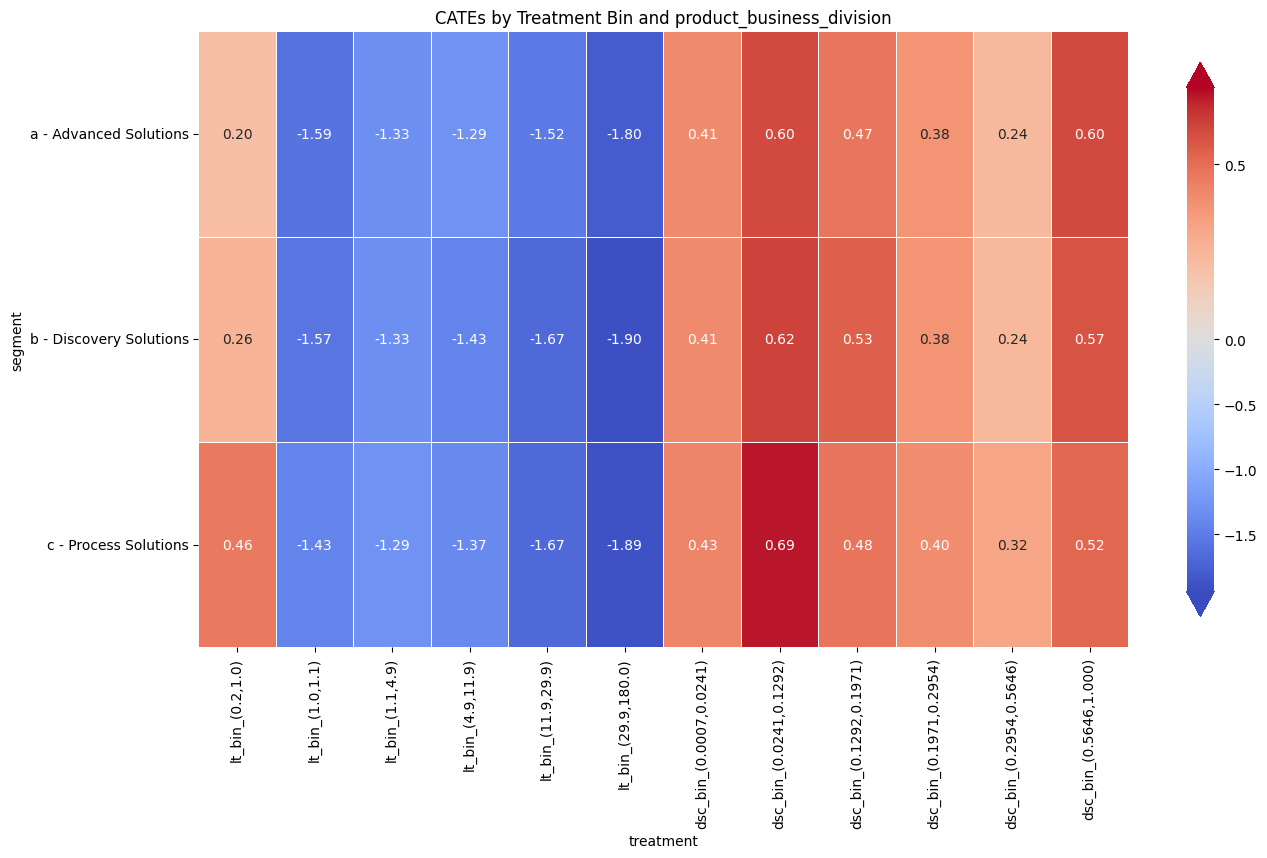

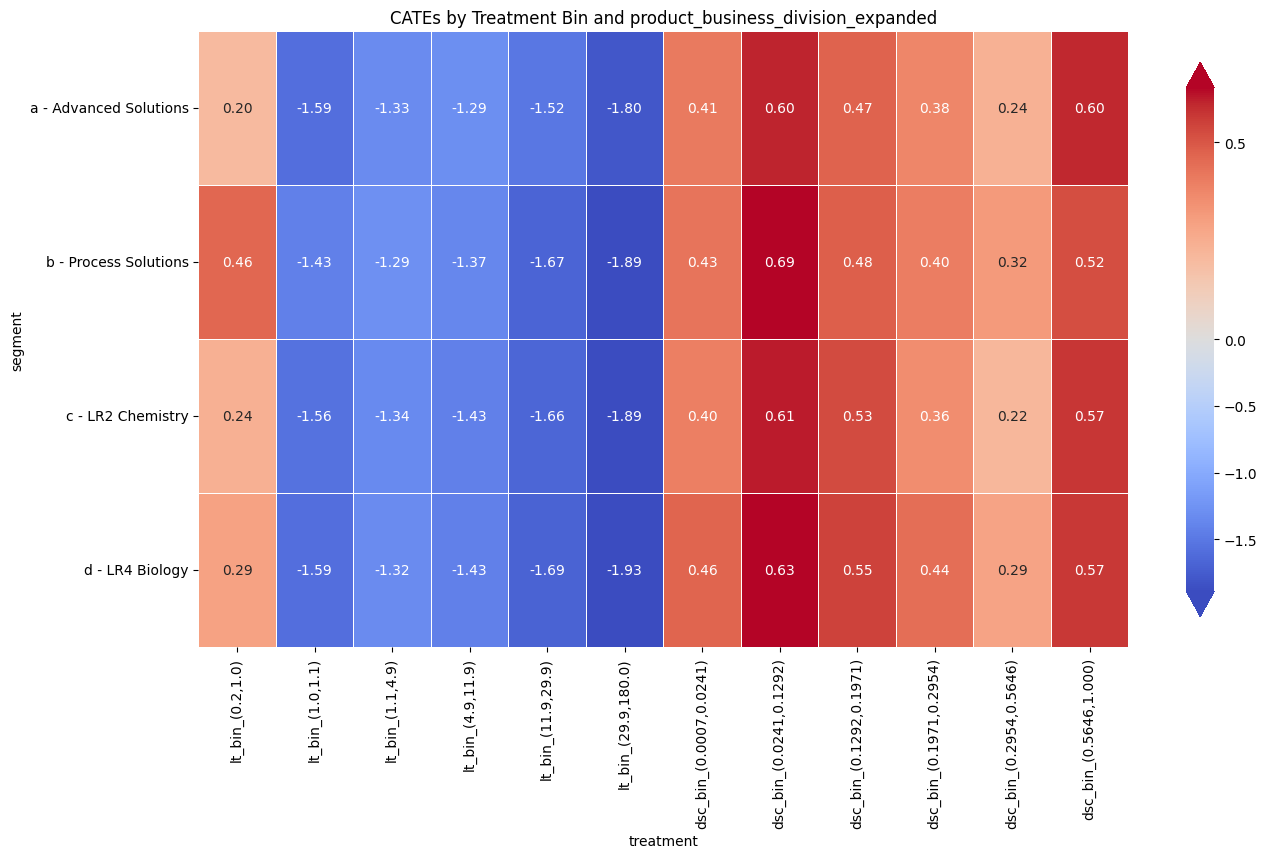

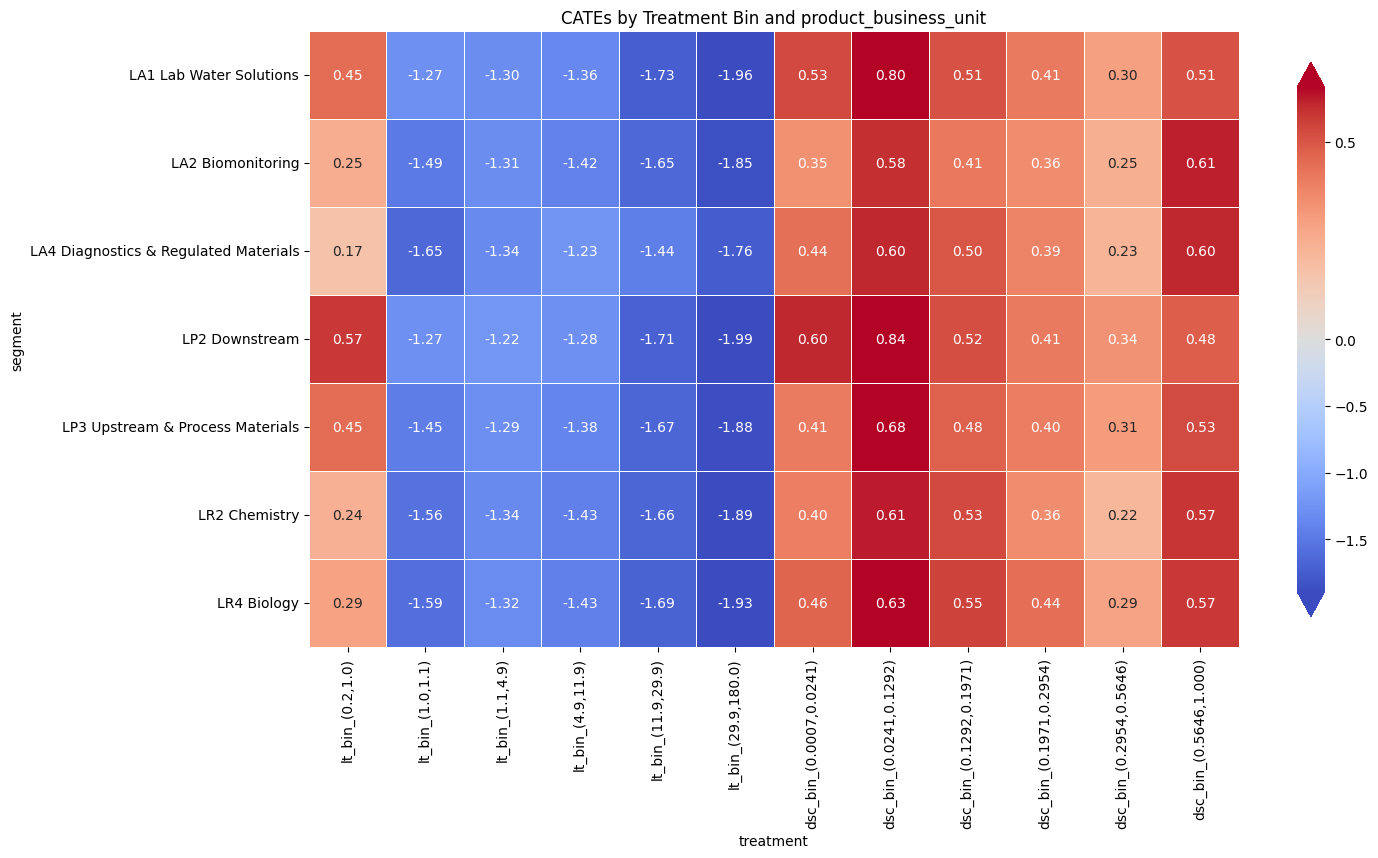

In [ ]:
import seaborn as sns
import matplotlib as mpl
import numpy as np

# 1) Robust bounds (2nd–98th pct), centereChrid at 0
#low, high = np.nanpercentile(heatmap_data.values, [2, 98])
#vmin = min(low, -1e-9)
#vmax = max(high, 1e-9)
#norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

df_heatmap = df_cate[df_cate['segment_type'] == 'product_business_division']

low, high = np.nanpercentile(heatmap_data.values, [2, 98])
vmin = min(low, -1e-9)
vmax = max(high, 1e-9)
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
##'product_business_division','product_business_division_expanded','product_business_unit'
maps = []
# 1) Grab the intended order as it appears in your data
bins_order = df_heatmap['treatment_bin'].drop_duplicates().tolist()

# 2) Pivot (use pivot_table to be safe with duplicates)
heatmap_data = (
    df_heatmap
      .pivot_table(index='segment',
                   columns='treatment_bin',
                   values='cate',
                   aggfunc='first',   # or 'mean' if you have duplicates per cell
                   sort=False)        # don't sort columns automatically
      .reindex(columns=bins_order)     # enforce your desired order
)
heatmap_data.loc[:, T_leads] = heatmap_data[T_leads].astype(float) - 1.5
maps.append(heatmap_data)
plt.figure(figsize=(15, 8))
#sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)
sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    norm=norm,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.9, 'extend': 'both'}
)
plt.title('CATEs by Treatment Bin and product_business_division')
plt.xlabel('treatment')
plt.ylabel('segment')
plt.yticks(rotation=0)
plt.show()


df_heatmap = df_cate[df_cate['segment_type'] == 'product_business_division_expanded']

low, high = np.nanpercentile(heatmap_data.values, [2, 98])
vmin = min(low, -1e-9)
vmax = max(high, 1e-9)
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

bins_order = df_heatmap['treatment_bin'].drop_duplicates().tolist()

# 2) Pivot (use pivot_table to be safe with duplicates)
heatmap_data = (
    df_heatmap
      .pivot_table(index='segment',
                   columns='treatment_bin',
                   values='cate',
                   aggfunc='first',   # or 'mean' if you have duplicates per cell
                   sort=False)        # don't sort columns automatically
      .reindex(columns=bins_order)     # enforce your desired order
)
heatmap_data.loc[:, T_leads] = heatmap_data[T_leads].astype(float) - 1.5
maps.append(heatmap_data)
# Plot
plt.figure(figsize=(15, 8))
#sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)
sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    norm=norm,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.9, 'extend': 'both'}
)
plt.title('CATEs by Treatment Bin and product_business_division_expanded')
plt.xlabel('treatment')
plt.ylabel('segment')
plt.yticks(rotation=0)
plt.show()


df_heatmap = df_cate[df_cate['segment_type'] == 'product_business_unit']
low, high = np.nanpercentile(heatmap_data.values, [2, 98])
vmin = min(low, -1e-9)
vmax = max(high, 1e-9)
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
bins_order = df_heatmap['treatment_bin'].drop_duplicates().tolist()

# 2) Pivot (use pivot_table to be safe with duplicates)
heatmap_data = (
    df_heatmap
      .pivot_table(index='segment',
                   columns='treatment_bin',
                   values='cate',
                   aggfunc='first',   # or 'mean' if you have duplicates per cell
                   sort=False)        # don't sort columns automatically
      .reindex(columns=bins_order)     # enforce your desired order
)
heatmap_data.loc[:, T_leads] = heatmap_data[T_leads].astype(float) - 1.5
maps.append(heatmap_data)
# Plot
plt.figure(figsize=(15, 8))
#sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)
sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    norm=norm,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.9, 'extend': 'both'}
)
plt.title('CATEs by Treatment Bin and product_business_unit')
plt.xlabel('treatment')
plt.ylabel('segment')
plt.yticks(rotation=0)
plt.show()

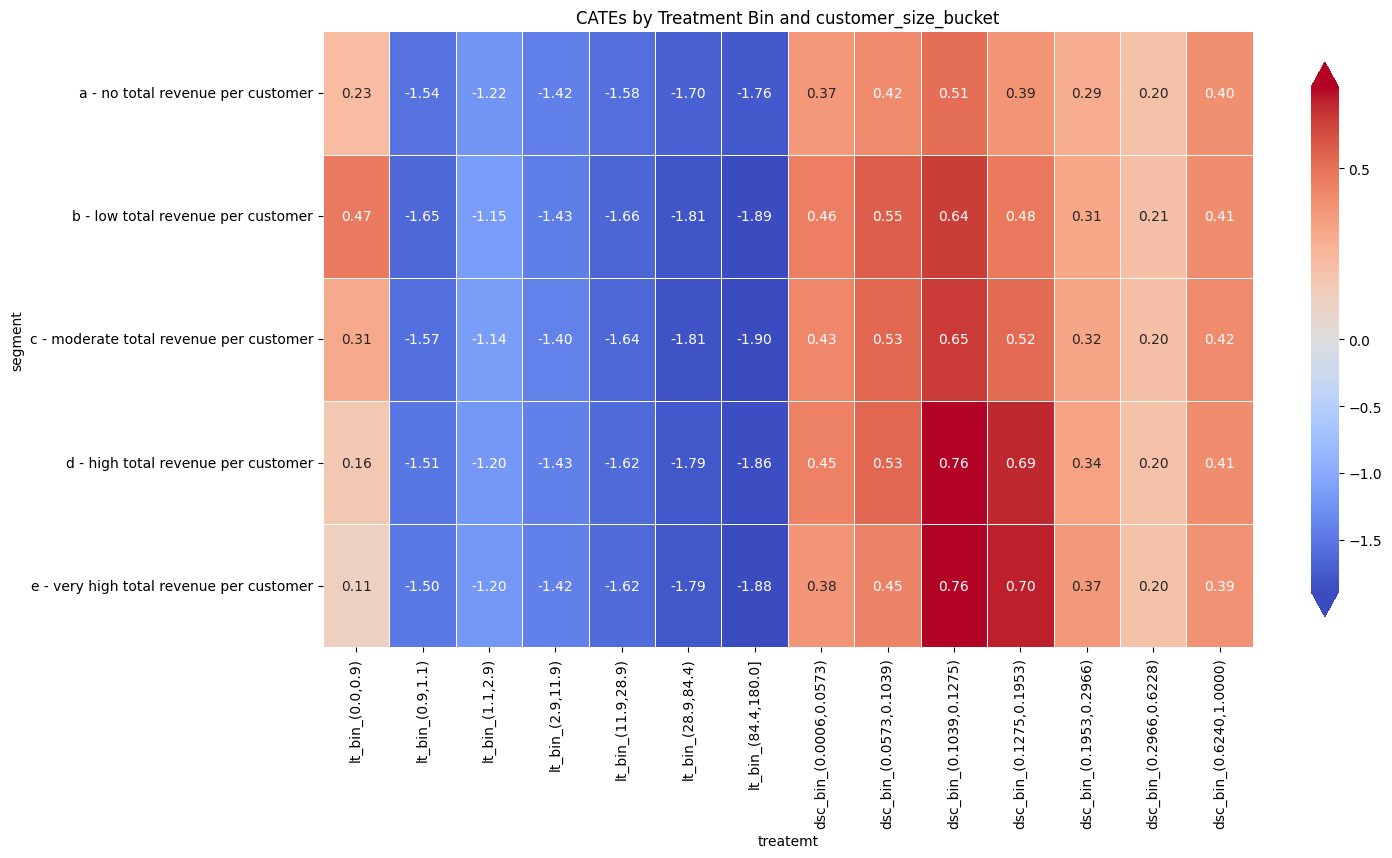

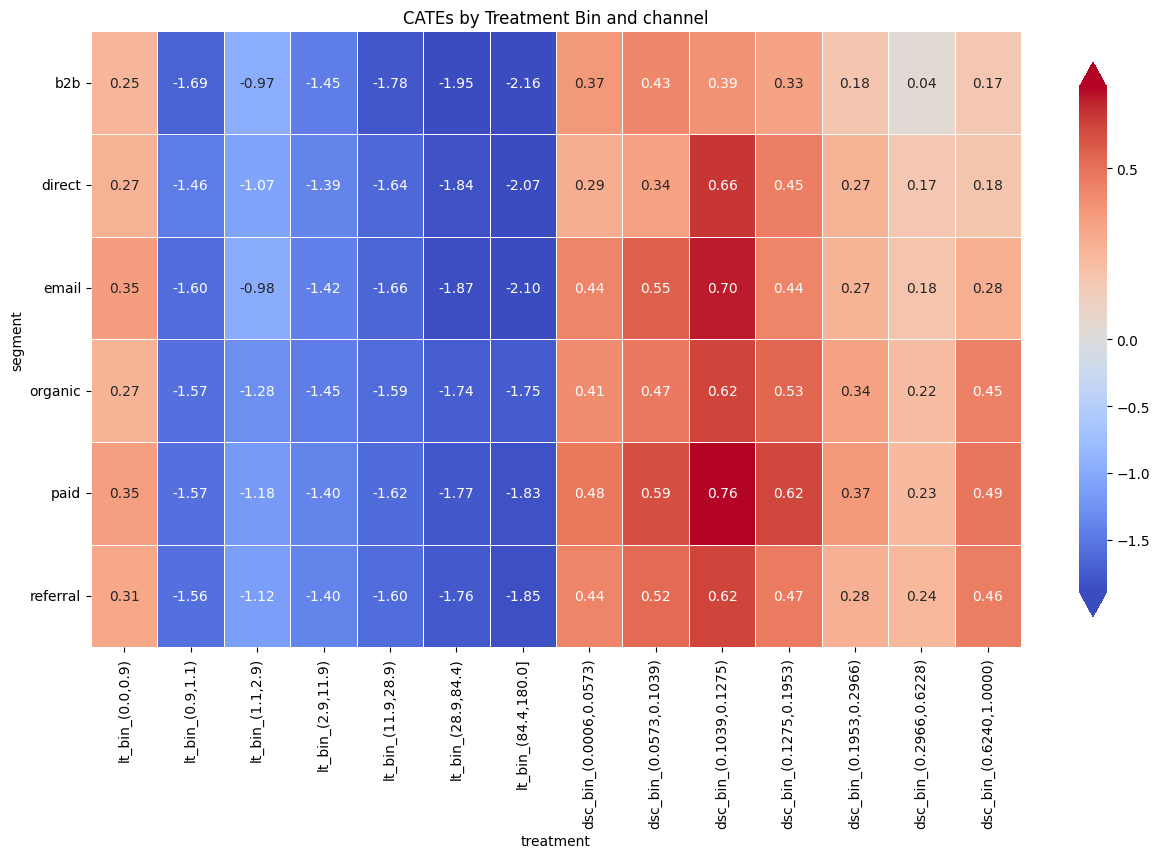

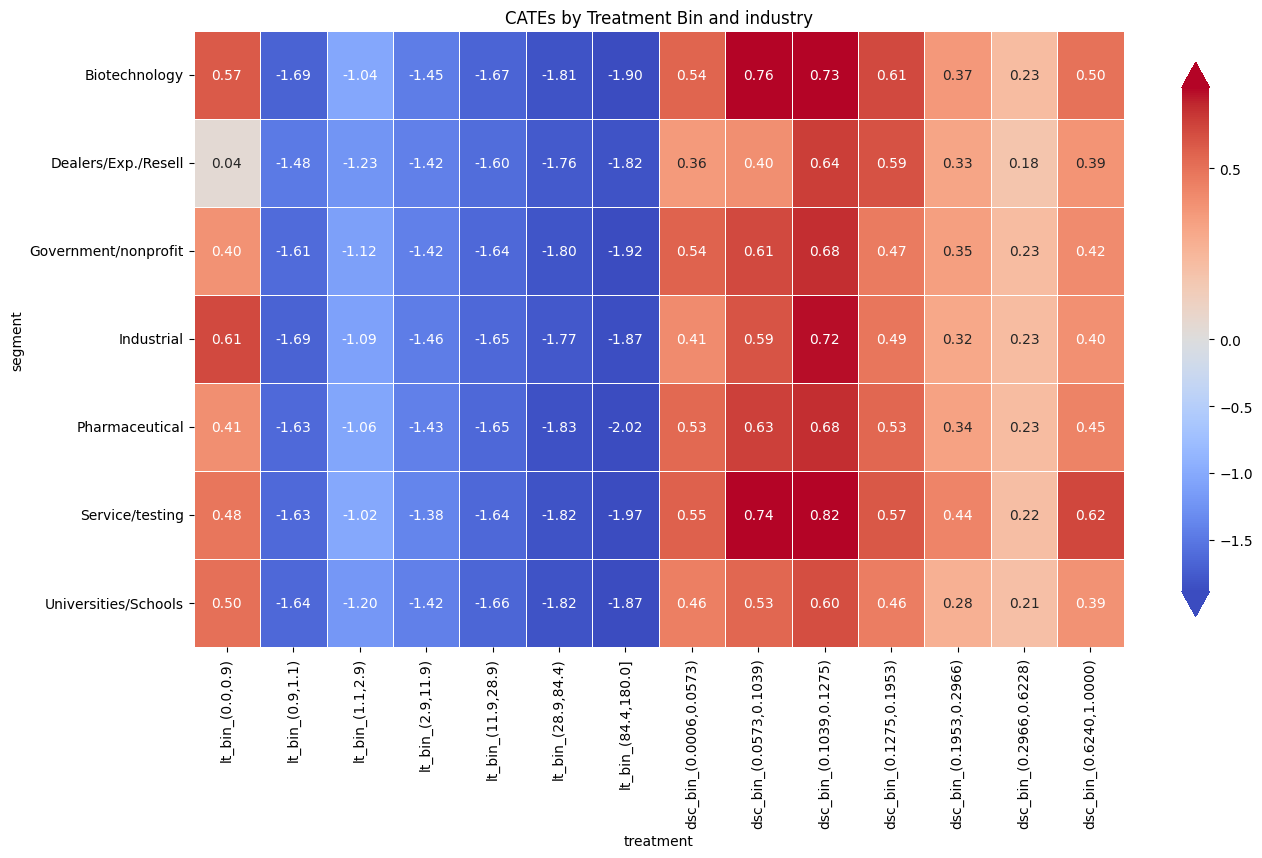

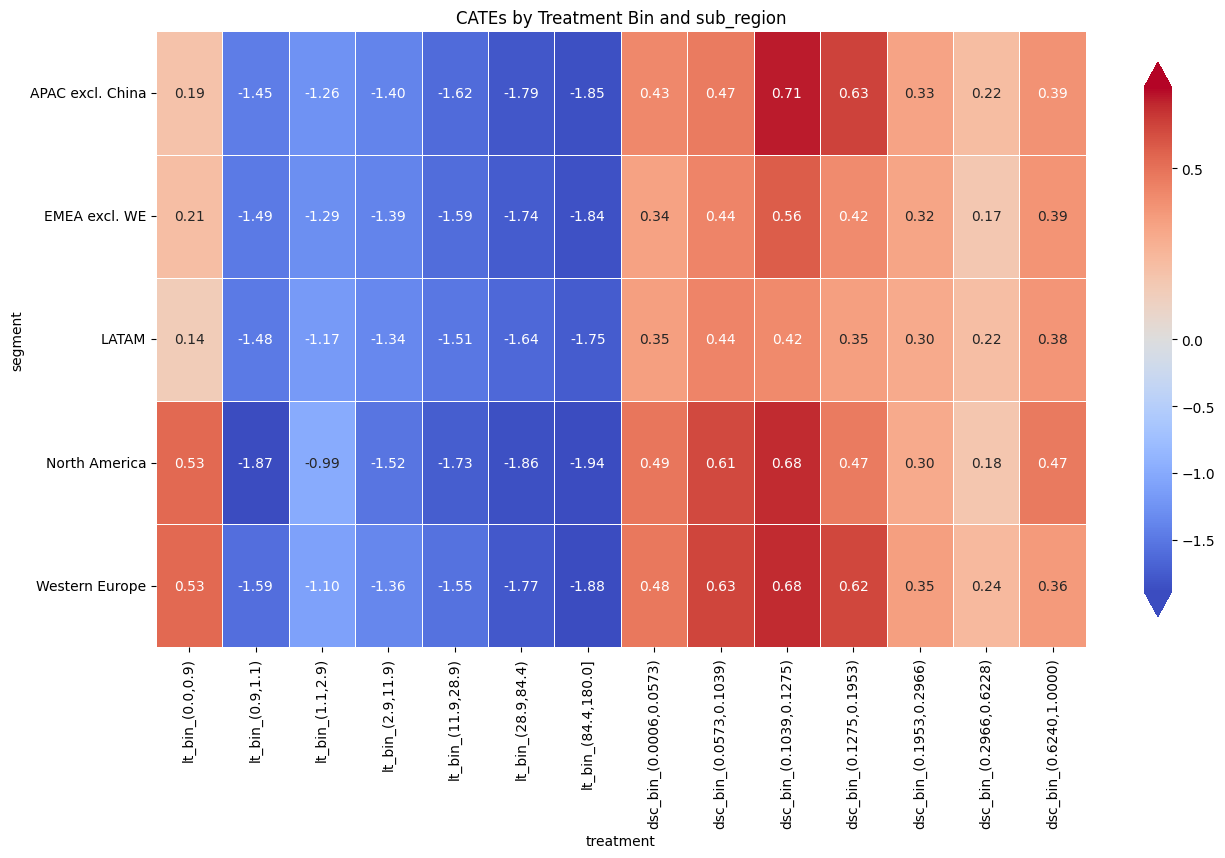

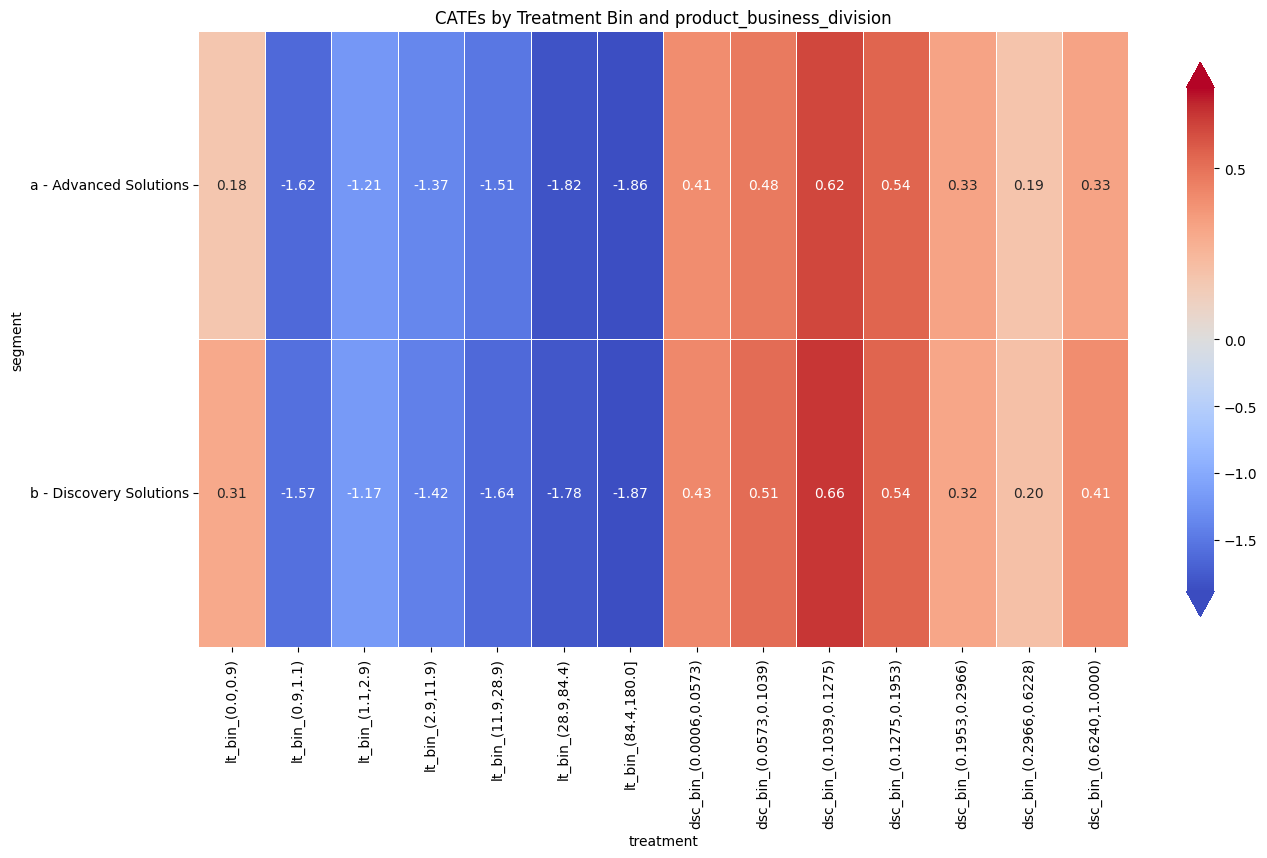

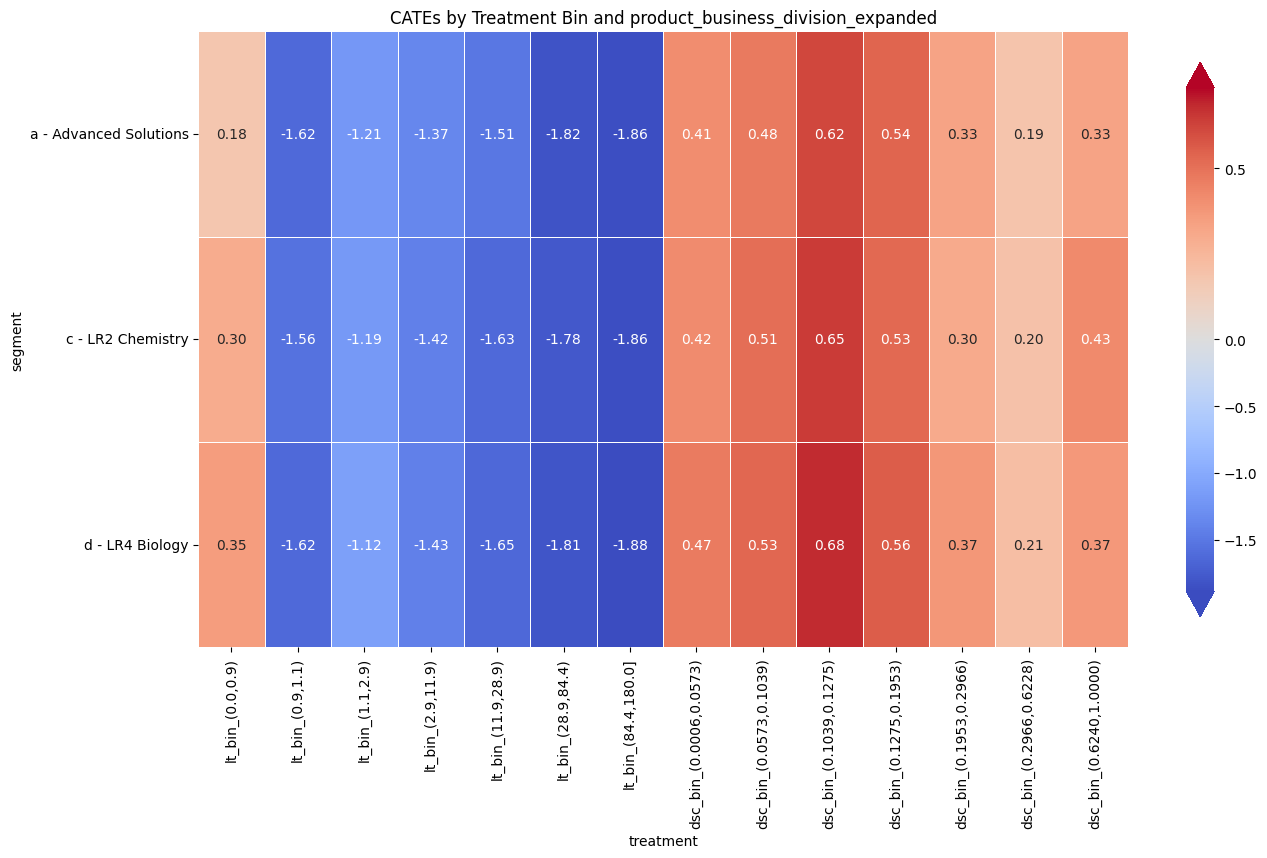

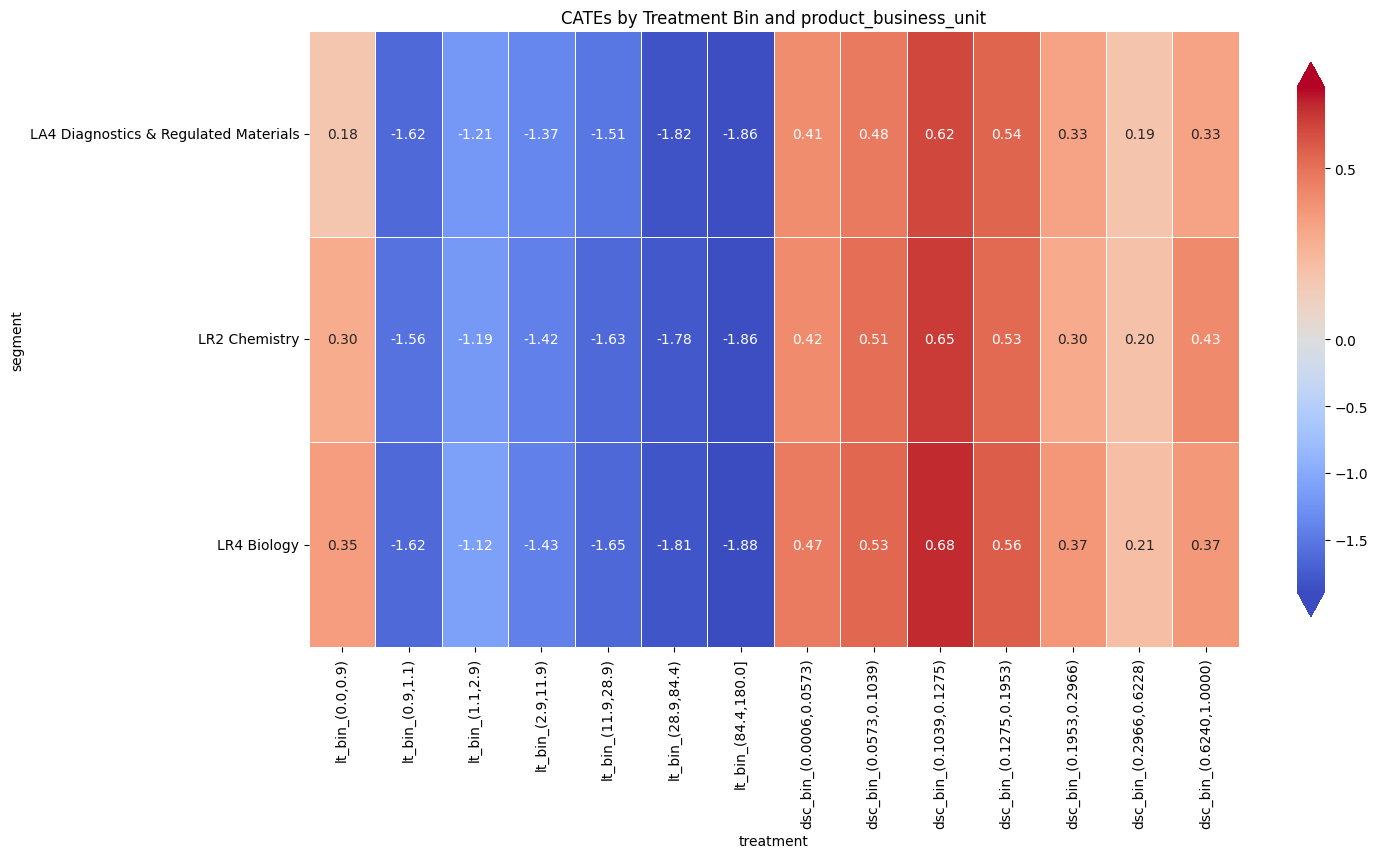

In [ ]:
import seaborn as sns
import matplotlib as mpl
import numpy as np

# 1) Robust bounds (2nd–98th pct), centered at 0
low, high = np.nanpercentile(heatmap_data.values, [2, 98])
vmin = min(low, -1e-9)
vmax = max(high, 1e-9)
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)



maps = []
df_heatmap = df_cate[df_cate['segment_type'] == 'customer_size_bucket'].copy()

# 1) Grab the intended order as it appears in your data
bins_order = df_heatmap['treatment_bin'].drop_duplicates().tolist()

# 2) Pivot (use pivot_table to be safe with duplicates)
heatmap_data = (
    df_heatmap
      .pivot_table(index='segment',
                   columns='treatment_bin',
                   values='cate',
                   aggfunc='first',   # or 'mean' if you have duplicates per cell
                   sort=False)        # don't sort columns automatically
      .reindex(columns=bins_order)     # enforce your desired order

)
heatmap_data.loc[:, T_leads] = heatmap_data[T_leads].astype(float) - 1.5
maps.append(heatmap_data)
# Plot
plt.figure(figsize=(15, 8))
#heatmap_data.columns = new_heatmap_cols
sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    norm=norm,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.9, 'extend': 'both'}
)
#sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)
plt.title('CATEs by Treatment Bin and customer_size_bucket')
plt.xlabel('treatemt')
plt.yticks(rotation=0)
plt.ylabel('segment')
plt.show()



# Filter
df_heatmap = df_cate[df_cate['segment_type'] == 'channel'].copy()

# 1) Grab the intended order as it appears in your data
bins_order = df_heatmap['treatment_bin'].drop_duplicates().tolist()

# 2) Pivot (use pivot_table to be safe with duplicates)
heatmap_data = (
    df_heatmap
      .pivot_table(index='segment',
                   columns='treatment_bin',
                   values='cate',
                   aggfunc='first',   # or 'mean' if you have duplicates per cell
                   sort=False)        # don't sort columns automatically
      .reindex(columns=bins_order)     # enforce your desired order
)
heatmap_data.loc[:, T_leads] = heatmap_data[T_leads].astype(float) - 1.5
maps.append(heatmap_data)
# Plot
plt.figure(figsize=(15, 8))
#heatmap_data.columns = new_heatmap_cols
#sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)
sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    norm=norm,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.9, 'extend': 'both'}
)

plt.title('CATEs by Treatment Bin and channel')
plt.xlabel('treatment')
plt.ylabel('segment')
plt.yticks(rotation=0)
plt.show()


df_heatmap = df_cate[df_cate['segment_type'] == 'industry'].copy()

# 1) Grab the intended order as it appears in your data
bins_order = df_heatmap['treatment_bin'].drop_duplicates().tolist()

# 2) Pivot (use pivot_table to be safe with duplicates)
heatmap_data = (
    df_heatmap
      .pivot_table(index='segment',
                   columns='treatment_bin',
                   values='cate',
                   aggfunc='first',   # or 'mean' if you have duplicates per cell
                   sort=False)        # don't sort columns automatically
      .reindex(columns=bins_order)     # enforce your desired order
)
heatmap_data.loc[:, T_leads] = heatmap_data[T_leads].astype(float) - 1.5
maps.append(heatmap_data)
# Plot
plt.figure(figsize=(15, 8))
#sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)
sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    norm=norm,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.9, 'extend': 'both'}
)
plt.title('CATEs by Treatment Bin and industry')
plt.xlabel('treatment')
plt.ylabel('segment')
plt.yticks(rotation=0)
plt.show()



df_heatmap = df_cate[df_cate['segment_type'] == 'sub_region']
# 1) Grab the intended order as it appears in your data
bins_order = df_heatmap['treatment_bin'].drop_duplicates().tolist()

# 2) Pivot (use pivot_table to be safe with duplicates)
heatmap_data = (
    df_heatmap
      .pivot_table(index='segment',
                   columns='treatment_bin',
                   values='cate',
                   aggfunc='first',   # or 'mean' if you have duplicates per cell
                   sort=False)        # don't sort columns automatically
      .reindex(columns=bins_order)     # enforce your desired order
)
heatmap_data.loc[:, T_leads] = heatmap_data[T_leads].astype(float) - 1.5
maps.append(heatmap_data)
# Plot
plt.figure(figsize=(15, 8))
#sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)
sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    norm=norm,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.9, 'extend': 'both'}
)
plt.title('CATEs by Treatment Bin and sub_region')
plt.xlabel('treatment')
plt.ylabel('segment')
plt.yticks(rotation=0)
plt.show()



In [ ]:
combined = pd.concat(maps)

# Compute column-wise mean
df_average = pd.DataFrame(combined.mean()).T
df_average.index = ['Average'] # Optional: name the single row


# Plotting the average values
#df_average.T.plot(kind='bar', legend=False)

#plt.title('Average Values Across All Maps')
#plt.ylabel('Average')
#plt.xlabel('Columns')
#plt.tight_layout()
#plt.show()

cols = df_average.columns
n = 5 # for example, first 3 columns orange, rest light blue

# Extract the values
values = df_average.loc['Average', cols]

# Define colors: first n orange, rest light blue
colors = ['orange'] * n + ['lightblue'] * (len(cols) - n)

# Plot
plt.figure(figsize=(12, 8))
plt.bar(cols, values, color=colors)
plt.title('Average Treatment Values')
plt.ylabel('Average')
plt.xlabel('Columns')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
LT = 'lead_time'  # the column to process

# =========================
# 0) Clean 'lead_time' and report max n
# =========================

# Ensure numericdf_copy['lead_time'] = pd.to_numeric(df_copy['lead_time'], errors='coerce').fillna(0)
df_copy.loc[:, LT] = pd.to_numeric(df_copy[LT], errors='coerce').fillna(0)

# Set negatives to 0
neg_mask = df_copy[LT] < 0
df_copy.loc[neg_mask, LT] = 0

# Max n after cleaning (ignore NaNs)
max_n = int(np.nanmax(df_copy[LT])) if df_copy[LT].notna().any() else 0
print(f"Max lead_time after clipping negatives: {max_n}")

# =========================
# 1) Binning utilities
# =========================

def make_lead_time_bins(df, col=LT, ks=(3,4,5), zero_label='[0]'):
    """
    For each k in ks, returns a Series of categorical bins where 0 is its own bin,
    and positive values are split into (k-1) quantile bins.
    """
    x = pd.to_numeric(df[col], errors='coerce')
    zero_mask = x.eq(0)
    results = {}

    for k in ks:
        qbins = k - 1
        if qbins <= 0:
            raise ValueError(f"k must be >= 2 to allow a zero bin + at least one positive bin (got k={k}).")

        s_obj = pd.Series(index=df.index, dtype=object)
        s_obj.loc[zero_mask] = zero_label

        pos_mask = (~zero_mask) & x.notna()
        if pos_mask.sum() > 0 and qbins > 0:
            # If too few unique values, qcut will drop duplicates automatically
            q = min(qbins, max(1, x[pos_mask].nunique()))
            qcuts = pd.qcut(x[pos_mask], q=q, duplicates='drop')
            s_obj.loc[pos_mask] = qcuts.astype(str).values
            cat_order = [zero_label] + [str(iv) for iv in qcuts.cat.categories]
        else:
            cat_order = [zero_label]

        s_cat = pd.Series(pd.Categorical(s_obj, categories=cat_order, ordered=True),
                          index=df.index, name=f'{col}_bin_k{k}')
        results[k] = s_cat

    return results


def evaluate_bin_series(binned_series: pd.Series):
    """
    Returns metrics: counts, proportions, num_bins, normalized entropy, CV of counts.
    """
    counts = binned_series.value_counts(sort=False)  # preserve category order
    n = counts.sum()
    props = counts / n if n > 0 else counts.astype(float)

    # Normalized Shannon entropy (0..1)
    p = props.replace(0, np.nan)
    H = float(-(p * np.log(p)).sum() / np.log(len(props))) if len(props) > 1 else 0.0

    # Coefficient of variation (std/mean) of counts
    cv = float(counts.std(ddof=0) / counts.mean()) if counts.mean() > 0 else np.inf

    return {
        'counts': counts,
        'proportions': props,
        'num_bins': len(props),
        'entropy_norm': H,
        'cv_counts': cv,
    }


def pick_best_binning(df, col=LT, ks=(3,4,5)):
    """
    Try k in ks, compute binning + metrics, and return:
      - best_k (by highest entropy, then lowest CV, then more bins),
      - all_results: dict of k -> {'series': ..., 'metrics': ...}
    """
    all_bins = make_lead_time_bins(df, col=col, ks=ks)
    all_results = {}

    for k, s in all_bins.items():
        metrics = evaluate_bin_series(s)
        all_results[k] = {'series': s, 'metrics': metrics}

    ranked = sorted(
        all_results.items(),
        key=lambda kv: (-kv[1]['metrics']['entropy_norm'],
                        kv[1]['metrics']['cv_counts'],
                        -kv[1]['metrics']['num_bins'])
    )
    best_k = ranked[0][0]
    return best_k, all_results


# =========================
# 2) Run binning and print summaries
# =========================

ks = (6,7,8)
best_k, results = pick_best_binning(df_copy, col=LT, ks=ks)

print(f"\nSelected best k: {best_k}\n")

for k in ks:
    m = results[k]['metrics']
    print(f"--- k={k} (effective bins={m['num_bins']}) ---")
    print("Counts:")
    print(m['counts'])
    print("Proportions:")
    print(m['proportions'].round(3))
    print(f"Entropy (normalized): {m['entropy_norm']:.3f} | CV(counts): {m['cv_counts']:.3f}\n")




gc.collect()
# =========================
# 3) Create features for the best binning
# =========================

best_series = results[best_k]['series']  # categorical with ordered categories

# (a) Save the categorical bin column
df_copy.loc[:, f'{LT}_bin_k{best_k}'] = best_series

# (b) Save an integer bin index (codes) column (-1 for NaN)
df_copy.loc[:, f'{LT}_bin_k{best_k}__idx'] = best_series.cat.codes.astype('int16')

# (c) One-hot columns (clean names)
def _numfmt(v):
    """Format numbers nicely: drop trailing .0 if integer-like."""
    try:
        fv = float(v)
        iv = int(round(fv))
        return str(iv) if abs(fv - iv) < 1e-9 else f'{fv:g}'
    except Exception:
        return str(v)
def _clean_bin_label(label: str):
    """
    Convert interval labels like '(1.0, 7.0]' -> '1_to_7'
    Keep zero bin '[0]' -> 'zero'
    """
    if label == '[0]':
        return 'zero'
    m = re.match(r'^[\(\[]\s*([-\d\.]+)\s*,\s*([-\d\.]+)\s*[\)\]]$', label)
    if m:
        lo = _numfmt(m.group(1))
        hi = _numfmt(m.group(2))
        return f'{lo}_to_{hi}'
    # Fallback: sanitize non-alnum to underscores
    return re.sub(r'[^0-9A-Za-z]+', '_', label)

# Create get_dummies and then rename columns to clean labels
dummies = pd.get_dummies(
    best_series,
    prefix=f'{LT}_bin_k{best_k}',
    prefix_sep='__',
    dtype='int8'
)

# Map original dummy column names to cleaned ones
rename_map = {}
prefix = f'{LT}_bin_k{best_k}__'
for cat in best_series.cat.categories:
    orig = f'{prefix}{str(cat)}'
    clean = f'{prefix}{_clean_bin_label(str(cat))}'
    rename_map[orig] = clean

dummies = dummies.rename(columns=rename_map)

# Attach to df_copy (no chained assignment)
for colname in dummies.columns:
    df_copy.loc[:, colname] = dummies[colname]

print(f"Created {dummies.shape[1]} one-hot columns for {LT}_bin_k{best_k}.")
gc.collect()

In [ ]:
# Column names
LP = 'list_price_per_item_euros'
DP = 'discounted_price_per_item_euros'
DC = 'discount_percentage'

cols = [LP, DP, DC]

# If df might be a view of another DataFrame, uncomment to avoid SettingWithCopyWarning
# df = df.copy()

# 0) Ensure numeric
df_copy[cols] = df_copy[cols].apply(pd.to_numeric, errors='coerce')

# 1) If any of the three is NaN, set all three to 0.0 (your original rule)
mask_nan = df_copy[cols].isna().any(axis=1)
df_copy.loc[mask_nan, cols] = 0.0

# 2) Fix inversions: list < discounted  -> set discounted = list, discount% = 0.0
mask_inverted = df_copy[LP] < df_copy[DP]
# set discounted to list for those rows
df_copy.loc[mask_inverted, DP] = df_copy.loc[mask_inverted, LP].to_numpy()
# set discount_percentage to 0.0 for those rows
df_copy.loc[mask_inverted, DC] = 0.0

# 3) Recompute discount_percentage from prices for ALL rows
#    Guard against division by zero or negative list prices.
lp = df_copy[LP]
dp = df_copy[DP]

with np.errstate(divide='ignore', invalid='ignore'):
    recomputed = (lp - dp) / lp

# Replace inf/-inf with NaN, then fill NaN where appropriate
recomputed = recomputed.replace([np.inf, -np.inf], np.nan)

# If list price <= 0 or recomputed is NaN, set discount to 0.0 (adjust to your policy)
invalid_list = lp <= 0
recomputed = recomputed.where(~invalid_list, 0.0).fillna(0.0)

# (Optional) Clip to [0, 1] so no values exceed 100% or go negative after fixes
recomputed = recomputed.clip(lower=0.0, upper=1.0)

# Write back with .loc to avoid chained assignment warning
df_copy.loc[:, DC] = recomputed

# 4) (Optional) Quick audit
n_inverted = int(mask_inverted.sum())
n_nan_rows = int(mask_nan.sum())
print(f"Rows set to 0 due to NaNs in any of {cols}: {n_nan_rows}")
print(f"Rows corrected where {LP} < {DP}: {n_inverted}")
print(df_copy[DC].describe(percentiles=[0.01, 0.5, 0.99]))
gc.collect()
ks = (6,7,9,10)  # try these totals (including the zero bin)
best_k, results = pick_best_binning(df_copy, col='discount_percentage', ks=ks)

# Attach the best binning to your DataFrame
best_series = results[best_k]['series']
df_copy.loc[:, f'discount_percentage_bin_k{best_k}'] = best_series

# Print a quick summary
print(f"Best k: {best_k}")
for k in ks:
    m = results[k]['metrics']
    print(f"\n--- k={k} (effective bins={m['num_bins']}) ---")
    print("Counts:\n", m['counts'])
    print("Proportions:\n", m['proportions'].round(3))
    print(f"Entropy (normalized): {m['entropy_norm']:.3f}  |  CV(counts): {m['cv_counts']:.3f}")
    gc.collect()


In [ ]:
def make_discount_bins(df, col='discount_percentage', ks=(4,5,6), zero_label='[0.0]'):
    """
    For each k in ks, returns a Series of categorical bins where 0.0 is its own bin,
    and non-zero values are split into (k-1) quantile bins.
    """
    # Safe numeric conversion
    x = pd.to_numeric(df[col], errors='coerce').fillna(0.0)

    zero_mask = (x == 0.0)
    results = {}

    for k in ks:
        qbins = k - 1
        if qbins <= 0:
            raise ValueError(f"k must be >= 2 to allow a zero bin + at least one non-zero bin (got k={k}).")

        # If all values are zero, everything is the zero bin
        if (~zero_mask).sum() == 0:
            s = pd.Series(pd.Categorical([zero_label] * len(x), categories=[zero_label], ordered=True),
                          index=df.index, name=f'{col}_bin_k{k}')
            results[k] = s
            continue
        # Try quantile bins on the non-zero portion
        nonzero_vals = x[~zero_mask]
        # If there are fewer unique values than desired bins, qcut will drop duplicates
        nonzero_bins = pd.qcut(nonzero_vals, q=min(qbins, max(1, nonzero_vals.nunique())),
                               duplicates='drop')

        # Build output series: zero bin + qcut bins
        s_obj = pd.Series(index=df.index, dtype=object)
        s_obj.loc[zero_mask] = zero_label
        s_obj.loc[~zero_mask] = nonzero_bins.astype(str).values

        # Order categories: zero first, then the qcut intervals in ascending order
        cat_order = [zero_label] + [str(iv) for iv in nonzero_bins.cat.categories]
        s_cat = pd.Series(pd.Categorical(s_obj, categories=cat_order, ordered=True),
                          index=df.index, name=f'{col}_bin_k{k}')
        results[k] = s_cat

    return results


def evaluate_bin_series(binned_series: pd.Series):
    """
    Returns a dictionary with counts, proportions, number of bins,
    normalized entropy (0..1), and coefficient of variation (CV) of bin counts.
    """
    counts = binned_series.value_counts(sort=False)  # preserve category order
    n = counts.sum()
    props = counts / n

    # Normalized Shannon entropy (max = 1 when perfectly even)
    # Handle zero probabilities cleanly
    p = props.replace(0, np.nan)
    H = float(-(p * np.log(p)).sum() / np.log(len(props))) if len(props) > 1 else 0.0

    # Coefficient of variation (std/mean) of counts
    cv = float(counts.std(ddof=0) / counts.mean()) if counts.mean() > 0 else np.inf

    return {
        'counts': counts,
        'proportions': props,
        'num_bins': len(props),
        'entropy_norm': H,
        'cv_counts': cv,
    }


def pick_best_binning(df, col='discount_percentage', ks=(4,5,6)):
    """
    Tries k in ks, computes binning + metrics, and returns:
      - best_k (by highest entropy, then lowest CV),
      - all_results: dict of k -> {'series': ..., 'metrics': ...}
    """
    all_bins = make_discount_bins(df, col=col, ks=ks)
    all_results = {}

    # Evaluate each k
    for k, s in all_bins.items():
        metrics = evaluate_bin_series(s)
        all_results[k] = {'series': s, 'metrics': metrics}

    # Rank: max entropy, then min CV, then more bins if tied
    ranked = sorted(
        all_results.items(),
        key=lambda kv: (-kv[1]['metrics']['entropy_norm'],
                        kv[1]['metrics']['cv_counts'],
                        -kv[1]['metrics']['num_bins'])
    )
    best_k = ranked[0][0]
    return best_k, all_results



ks = (7,9,10)  # try these totals (including the zero bin)
best_k, results = pick_best_binning(df_copy, col='discount_percentage', ks=ks)



# Attach the best binning to your DataFrame
best_series = results[best_k]['series']
df_copy.loc[:, f'discount_percentage_bin_k{best_k}'] = best_series

# Print a quick summary
print(f"Best k: {best_k}")
for k in ks:
    m = results[k]['metrics']
    print(f"\n--- k={k} (effective bins={m['num_bins']}) ---")
    print("Counts:\n", m['counts'])
    print("Proportions:\n", m['proportions'].round(3))
    print(f"Entropy (normalized): {m['entropy_norm']:.3f}  |  CV(counts): {m['cv_counts']:.3f}")


binned = best_series  # a categorical Series aligned to df_copy's index

# Add the label column (optional)
df_copy.loc[:, binned.name or 'discount_bin'] = binned

# One-hot per bin
dummies = pd.get_dummies(binned, prefix=binned.name or 'discount_bin', dtype='int8')
df_copy = df_copy.join(dummies)

# Ensure exactly one bin per row
assert (dummies.sum(axis=1) == 1).all(), "Each row should belong to exactly one bin."


import re

def clean_col(s: str) -> str:
    # Example: "discount_percentage_bin_(0.1, 0.2]" -> "discount_bin_0p1_to_0p2"
    s = s.replace('discount_percentage_bin_', 'discount_bin_')
    s = s.replace('(-inf, ', 'lt_').replace(', inf]', '_plus')
    s = s.replace('[', '').replace('(', '').replace(']', '').replace(')', '')
    s = re.sub(r'\s+', '', s)
    s = s.replace(',', '_to_').replace('.', 'p').replace('-', 'm')
    return s

dummies_clean = dummies.copy()
dummies_clean.columns = [clean_col(c) for c in dummies.columns]

# Swap in the cleaned columns if you prefer those names
df_copy = df_copy.drop(columns=dummies.columns).join(dummies_clean)

In [ ]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
from IPython.display import display
display(df_with_bins.loc[39:40, :])
gc.collect()

In [ ]:
import itertools
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.cross_decomposition import PLSRegression
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Configuration
# -----------------------------
product_col = "product_variant"
revenue_col = "discounted_price_per_item_euros"

revenue_share_threshold = 0.65
pls_components = 9
top_n_for_heatmap = 100
random_state = 42
n_splits_oof = 5
smoothing = 10.0 # smoothing for target encoding
combination_size = 2 # integer >1; controls number of features combined for interaction-like encodings

# Example additional categorical columns you may have
# If you only have product_id, combination_size>1 will only combine repeats of product_id (no-op).
# Provide other categorical columns like 'category', 'brand', 'region' if available.
categorical_columns = ["product_group"] # will be updated after product grouping assignment
# If you have real columns, set categorical_columns = ["product_group", "brand", "category", "region"]


# -----------------------------
# Helpers
# -----------------------------
def compute_top_products(df: pd.DataFrame, product_col: str, revenue_col: str, target_share: float = 0.40) -> Tuple[set, pd.Series]:
    prod_rev = df.groupby(product_col, sort=False)[revenue_col].sum()
    prod_rev = prod_rev.sort_values(ascending=False)
    cumshare = prod_rev.cumsum() / prod_rev.sum()
    cutoff_idx = np.searchsorted(cumshare.values, target_share, side="right")
    if cutoff_idx == 0:
        cutoff_idx = 1
    top_products = prod_rev.index[:cutoff_idx]
    return set(top_products), prod_rev


def assign_product_group(df: pd.DataFrame, top_products_set: set, product_col: str) -> pd.DataFrame:
    df2 = df.copy()
    isin_top = df2[product_col].isin(top_products_set)
    df2["product_group"] = df2[product_col].astype(str).where(isin_top, other="other_products")
    return df2


def make_combined_cat_columns(
    df: pd.DataFrame, cat_cols: List[str], comb_size: int
) -> Tuple[pd.DataFrame, List[str]]:
    """
    Create combined categorical columns by concatenating values of combinations of cat_cols of size comb_size.
    Returns df with new columns added and list of new column names.
    """
    if comb_size <= 1:
        return df, []
    combs = list(itertools.combinations(cat_cols, comb_size))
    new_cols = []
    for c in combs:
        col_name = "comb__" + "__".join(c)
        # join as strings with '||' separator to avoid accidental collisions
        df[col_name] = df[list(c)].astype(str).agg("||".join, axis=1)
        new_cols.append(col_name)
    return df, new_cols


def catboost_style_target_encode_oof_for_cols(
    df: pd.DataFrame,
    cols: List[str],
    target_col: str,
    n_splits: int = 5,
    seed: int = 42,
    smoothing: float = 10.0,
) -> Tuple[pd.DataFrame, Dict[str, pd.Series]]:
    """
    For every column in cols, produce an OOF target-encoded numeric column based on log1p(target_col).
    Returns:
      - df copy with new columns appended named <col>__cb_te
      - mapping dict col -> Series (global smoothed mean per category) for future transforms
    """
    df_out = df.copy()
    y = np.log1p(df_out[target_col].values)
    global_mean = y.mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    mappings = {}
    for col in cols:
        col_vals = df_out[col].astype(str).values
        oof = np.zeros(len(df_out), dtype=np.float64)

        # OOF loop
        for train_idx, valid_idx in kf.split(df_out):
            train_vals = col_vals[train_idx]
            train_y = y[train_idx]
            # compute group mean and count on train
            grp_mean = pd.Series(train_y).groupby(train_vals).mean()
            grp_count = pd.Series(train_y).groupby(train_vals).count()
            # map for valid
            valid_keys = col_vals[valid_idx]
            mapped_mean = pd.Series(valid_keys).map(grp_mean).astype(float)
            counts = pd.Series(valid_keys).map(grp_count).fillna(0).astype(float)
            # smoothing: (count*group_mean + smoothing*global_mean) / (count + smoothing)
            smoothed = np.where(np.isnan(mapped_mean), global_mean, (counts * mapped_mean + smoothing * global_mean) / (counts + smoothing))
            oof[valid_idx] = smoothed

        # global mapping on all data (for downstream / apply)
        all_grp_mean = pd.Series(y).groupby(col_vals).mean()
        all_grp_count = pd.Series(y).groupby(col_vals).count()
        global_smoothed = pd.Series({g: (all_grp_count.loc[g] * all_grp_mean.loc[g] + smoothing * global_mean) / (all_grp_count.loc[g] + smoothing) for g in all_grp_mean.index})

        new_colname = f"{col}__cb_te"
        df_out[new_colname] = oof
        mappings[col] = global_smoothed

    return df_out, mappings


def fit_pls_and_get_scores(
    df: pd.DataFrame, feature_cols: List[str], target_col: str, n_components: int = 12
) -> Tuple[PLSRegression, np.ndarray, List[str]]:
    """
    Fit PLSRegression on log1p(target) using feature_cols numeric features.
    Returns:
      - fitted PLS object
      - sample-level PLS component scores (n_samples x n_components)
      - list of column names for components
    """
    X = df[feature_cols].values.astype(float)
    Y = np.log1p(df[target_col].values).reshape(-1, 1)
    pls = PLSRegression(n_components=n_components)
    pls.fit(X, Y)
    scores = pls.transform(X) # (n_samples, n_components)
    comp_cols = [f"pls_comp_{i}" for i in range(scores.shape[1])]
    return pls, scores, comp_cols


def per_product_centroid_scores(df: pd.DataFrame, product_col: str, score_cols: List[str]) -> pd.DataFrame:
    """
    Aggregate sample-level scores by product (mean).
    Returns DataFrame indexed by product_col with mean scores and total_revenue.
    """
    scores_df = pd.DataFrame(df[score_cols], index=df.index)
    scores_df[product_col] = df[product_col].values
    centroids = scores_df.groupby(product_col).mean()
    # add total revenue per product for sorting/selection
    total_rev = df.groupby(product_col)[revenue_col].sum()
    centroids = centroids.join(total_rev.rename("total_revenue"))
    centroids = centroids.sort_values("total_revenue", ascending=False)
    return centroids


def plot_heatmap(matrix: np.ndarray, row_labels: List[str], col_labels: List[str], title: str = None, figsize=(10, 28)):
    plt.figure(figsize=figsize)
    sns.heatmap(matrix, xticklabels=col_labels, yticklabels=row_labels, cmap="vlag", center=0.0)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()


# -----------------------------
# Full pipeline
# -----------------------------
def pipeline_with_combination_encoding(
    df: pd.DataFrame,
    product_col: str,
    revenue_col: str,
    revenue_share_threshold: float,
    combination_size: int,
    additional_cat_cols: List[str],
    pls_components: int,
    top_n_for_heatmap: int,
    n_splits_oof: int = 5,
    smoothing: float = 10.0,
    random_state: int = 42,
):
    # 1) Identify top products
    top_products_set, prod_rev = compute_top_products(df, product_col, revenue_col, revenue_share_threshold)
    print(f"Identified {len(top_products_set)} top products that cover ~{int(revenue_share_threshold*100)}% revenue")

    # 2) Assign product_group
    df2 = assign_product_group(df, top_products_set, product_col)

    # Update categorical_columns to include product_group and any additional provided columns
    cat_cols = ["product_group"] + [c for c in additional_cat_cols if c != product_col and c != "product_group"]
    # Ensure these columns exist in df2; if not, raise or warn
    missing = [c for c in cat_cols if c not in df2.columns]
    if missing:
        raise ValueError(f"Missing categorical columns in dataframe required for combination encoding: {missing}")

    # 3) Create combined categorical columns for combinations of size combination_size
    df2_with_comb, new_comb_cols = make_combined_cat_columns(df2, cat_cols, combination_size)
    print(f"Created {len(new_comb_cols)} combined categorical columns: {new_comb_cols}")

    # 4) Prepare list of columns to encode: single-feature cat cols + combined cols
    cols_to_encode = cat_cols + new_comb_cols

    # 5) Run CatBoost-style OOF target encoding for all columns in cols_to_encode
    print(f"Performing CatBoost-style OOF target encoding for {len(cols_to_encode)} columns...")
    df_encoded, mappings = catboost_style_target_encode_oof_for_cols(
        df2_with_comb,
        cols=cols_to_encode,
        target_col=revenue_col,
        n_splits=n_splits_oof,
        seed=random_state,
        smoothing=smoothing,
    )
    # new encoded column names
    encoded_cols = [f"{c}__cb_te" for c in cols_to_encode]

    # 6) Fit PLS on these encoded numeric columns
    print(f"Fitting PLS on {len(encoded_cols)} encoded columns with n_components={pls_components} ...")
    pls, scores, comp_cols = fit_pls_and_get_scores(df_encoded, encoded_cols, revenue_col, n_components=pls_components)

    # append scores to df_encoded
    scores_df = pd.DataFrame(scores, columns=comp_cols, index=df_encoded.index)
    df_encoded = pd.concat([df_encoded, scores_df], axis=1)

    # 7) Aggregate per-product centroids on the PLS components
    centroids = per_product_centroid_scores(df_encoded, product_col, comp_cols)

    # 8) Select top N products by total_revenue for visualization
    top_centroids = centroids.head(top_n_for_heatmap)
    heatmap_matrix = top_centroids[comp_cols].values
    heatmap_product_labels = top_centroids.index.astype(str).tolist()

    # 9) Return artifacts
    artifacts = {
        "df_encoded": df_encoded,
        "mappings": mappings,
        "encoded_cols": encoded_cols,
        "pls": pls,
        "pls_comp_cols": comp_cols,
        "centroids": centroids,
        "top_centroids": top_centroids,
        "heatmap_matrix": heatmap_matrix,
        "heatmap_product_labels": heatmap_product_labels,
    }
    return artifacts


# -----------------------------
# Example usage
# -----------------------------
# df should be your DataFrame with at least 'product_id' and 'revenue' and any extra categorical columns you want combined with product_group
# Example: suppose df has ['product_id', 'revenue', 'brand', 'category', 'region']
additional_cat_cols = ['channel'	,'industry' , 'sub_region' ,'warehouse', 'product_brand','customer_size_bucket'] # exclude product_id; product_group will be added automatically
#cat_cols = ['channel'	,'industry' , 'sub_region' ,'warehouse', 'product_brand','customer_size_bucket']#cat_col_trim = ['channel'	,'industry' , 'sub_region' ,'customer_size_bucket']#'warehouse','product_brand'
# Replace with your actual df and additional categorical columns
# df = pd.read_parquet("your_data.parquet")
# additional_cat_cols = ['brand', 'category', 'region'] # or [] if not available

artifacts = pipeline_with_combination_encoding(
df=df_copy.copy(),
product_col=product_col,
revenue_col=revenue_col,
revenue_share_threshold=revenue_share_threshold,
combination_size=combination_size,
additional_cat_cols=additional_cat_cols,
pls_components=pls_components,
top_n_for_heatmap=top_n_for_heatmap,
n_splits_oof=n_splits_oof,
smoothing=smoothing,
random_state=random_state
)

# Then plot:
plot_heatmap(artifacts["heatmap_matrix"], artifacts["heatmap_product_labels"], artifacts["pls_comp_cols"],
title=f"Top {top_n_for_heatmap} products vs {pls_components} PLS components")
import gc
gc.collect()
# -----------------------------
# Explanation of encoded columns created
# -----------------------------
# For each column in cat_cols (which includes product_group and any provided categorical columns), the pipeline creates:
# <col>__cb_te -- the CatBoost-style OOF target-encoded numeric column (log1p-revenue based, smoothed)
# For each combination of columns of size combination_size, the pipeline creates:
# comb__colA__colB -- string column (concatenated values)
# comb__colA__colB__cb_te -- numeric OOF target-encoded column for that combination
#
# Those numeric encoded columns are collected into encoded_cols and used as predictors for PLS.


In [ ]:
import numpy as np
import pandas as pd

def compute_pls_vip(pls):
    """
    Compute VIP scores for a fitted sklearn PLSRegression model.
    Works for PLS1 and PLS2 (multiple Y) models.

    Returns
    -------
    vip : np.ndarray shape (n_features,)
    """
    # Scores (T), X weights (W), Y loadings (Q)
    T = pls.x_scores_                  # (n_samples, n_components)
    W = pls.x_weights_                 # (n_features, n_components)
    Q = pls.y_loadings_                # (n_targets, n_components)

    p, A = W.shape  # features, components

    # SSY per component: ||t_a||^2 * ||q_a||^2
    ssy = (T**2).sum(axis=0) * (Q**2).sum(axis=0)   # shape (A,)
    total_ssy = ssy.sum()
    if total_ssy == 0:
        # degenerate case (e.g., constant y); avoid div-by-zero
        return np.zeros(W.shape[0])

    # Normalize weights per component by their L2 norm
    W_norm_sq = (W**2).sum(axis=0)  # ||w_a||^2, shape (A,)
    # Avoid division by zero for degenerate components
    W_norm_sq = np.where(W_norm_sq == 0, 1.0, W_norm_sq)

    # Compute VIP per feature
    vip = np.zeros(p)
    for j in range(p):
        # Contribution of feature j across components
        contrib = ssy * (W[j, :]**2 / W_norm_sq)
        vip[j] = np.sqrt(p * contrib.sum() / total_ssy)

    return vip

def vip_table(pls, feature_names, sort=True):
    vip = compute_pls_vip(pls)
    # Direction can be reported from the overall regression coefficients
    # (sign only; VIP itself is unsigned)
    coef = np.ravel(pls.coef_)  # for PLS1; if PLS2, you can handle per target
    sign = np.sign(coef) if coef.ndim == 1 else np.zeros_like(vip)

    # Explicit length check for clarity and robust error handling
    if len(feature_names) != len(vip):
        raise ValueError(
            f"Mismatched lengths: feature_names ({len(feature_names)}) must match "
            f"the number of features in PLS model ({len(vip)}). "
            "Please ensure 'feature_names' corresponds to the input features used to train the PLS model."
            "If you intend to analyze products, a different method to relate VIP scores to products would be needed."
        )

    df = pd.DataFrame({
        "feature": feature_names,
        "vip": vip,
        "coef": coef, # coef should already match vip length
        "sign": sign # sign should already match vip length
    })
    if sort:
        df = df.sort_values("vip", ascending=False).reset_index(drop=True)
    return df

# Example:
# pls = PLSRegression(n_components=3, scale=True).fit(X, y)
# df_vip = vip_table(pls, X.columns)
# print(df_vip.head(10))


#from sklearn.cross_decomposition import PLSRegression

# Fit
#pls = PLSRegression(n_components=3, scale=True).fit(X, y)

# (A) Top/bottom by absolute weight on Component 1 (idx 0)
#wb = top_by_pls_weights(pls, feature_names=X.columns, component=0, top_k=10, bottom_j=10)
#print("Top 10 by |weight| (comp 1):\n", wb["top"])
#print("\nBottom 10 by |weight| (comp 1):\n", wb["bottom"])

# (B) Top 10 by VIP across all components
#print(len(artifacts["pls"]))
print(len(artifacts["encoded_cols"]))
df_vip = vip_table(artifacts["pls"], feature_names=artifacts["encoded_cols"])
print("\nTop 10 by VIP:\n", df_vip.head(10))


In [ ]:
def top_bottom_by_column(matrix, labels, k=10, j=10, column=0, drop_na=True):
    """
    Return top-k largest and bottom-j smallest by a specified column.

    Parameters
    ----------
    matrix : np.ndarray (n_rows, n_cols)
        The matrix of values.
    labels : Sequence[str]
        Labels corresponding to rows (length n_rows).
    k : int
        Number of largest values to return.
    j : int
        Number of smallest values to return.
    column : int
        Column index to rank by.
    drop_na : bool
        If True, exclude NaN and ±inf from consideration.
        If False, NaN is treated as -inf for TOP (so it won't appear)
                 and as +inf for BOTTOM (so it won't appear).

    Returns
    -------
    dict with keys "top" and "bottom", each a list of tuples:
      (row_index, label, value)
      - "top" is sorted descending (largest → smallest)
      - "bottom" is sorted ascending (smallest → largest)
    """
    import numpy as np

    col = matrix[:, column]

    # --- Build views for TOP and BOTTOM according to drop_na policy ---
    if drop_na:
        valid = np.isfinite(col)  # excludes NaN and ±inf
        idx_valid = np.where(valid)[0]
        col_top = col[valid]
        col_bottom = col[valid]
    else:
        # For TOP: push NaNs to very small so they won't be selected
        col_top_full = np.where(np.isnan(col), -np.inf, col)
        # For BOTTOM: push NaNs to very large so they won't be selected
        col_bottom_full = np.where(np.isnan(col), np.inf, col)
        idx_valid = np.arange(col.shape[0])
        col_top = col_top_full
        col_bottom = col_bottom_full

    # Early return if nothing valid
    if idx_valid.size == 0:
        return {"top": [], "bottom": []}

    # --- TOP K (largest) ---
    k_eff = int(min(max(k, 0), idx_valid.size))
    if k_eff > 0:
        # Argpartition to get top-k candidates, then sort them desc
        top_unsorted_local = np.argpartition(col_top, -k_eff)[-k_eff:]
        top_global_idx = idx_valid[top_unsorted_local]
        top_sorted = top_global_idx[np.argsort(col[top_global_idx])[::-1]]
        top_result = [(int(i), labels[int(i)], float(col[int(i)])) for i in top_sorted]
    else:
        top_result = []

    # --- BOTTOM J (smallest) ---
    j_eff = int(min(max(j, 0), idx_valid.size))
    if j_eff > 0:
        bottom_unsorted_local = np.argpartition(col_bottom, j_eff - 1)[:j_eff]
        bottom_global_idx = idx_valid[bottom_unsorted_local]
        bottom_sorted = bottom_global_idx[np.argsort(col[bottom_global_idx])]
        bottom_result = [(int(i), labels[int(i)], float(col[int(i)])) for i in bottom_sorted]
    else:
        bottom_result = []

    return {"top": top_result, "bottom": bottom_result}


res = top_bottom_by_column(artifacts["heatmap_matrix"], artifacts["heatmap_product_labels"], k=10, j=10, column=0, drop_na=True)

print("Top 10:")
for r, (i, lbl, val) in enumerate(res["top"], 1):
    print(f"{r:2d}. idx={i:4d}  label={lbl}  value={val}")

print("\nBottom 10:")
for r, (i, lbl, val) in enumerate(res["bottom"], 1):
    print(f"{r:2d}. idx={i:4d}  label={lbl}  value={val}")

print("----------------------------\n")

res = top_bottom_by_column(artifacts["heatmap_matrix"], artifacts["heatmap_product_labels"], k=10, j=10, column=1, drop_na=True)
print("Top 10:")
for r, (i, lbl, val) in enumerate(res["top"], 1):
    print(f"{r:2d}. idx={i:4d}  label={lbl}  value={val}")

print("\nBottom 10:")
for r, (i, lbl, val) in enumerate(res["bottom"], 1):
    print(f"{r:2d}. idx={i:4d}  label={lbl}  value={val}")



print("----------------------------\n")

res = top_bottom_by_column(artifacts["heatmap_matrix"], artifacts["heatmap_product_labels"], k=10, j=10, column=2, drop_na=True)
print("Top 10:")
for r, (i, lbl, val) in enumerate(res["top"], 1):
    print(f"{r:2d}. idx={i:4d}  label={lbl}  value={val}")

print("\nBottom 10:")
for r, (i, lbl, val) in enumerate(res["bottom"], 1):
    print(f"{r:2d}. idx={i:4d}  label={lbl}  value={val}")

print("----------------------------\n")

res = top_bottom_by_column(artifacts["heatmap_matrix"], artifacts["heatmap_product_labels"], k=10, j=10, column=3, drop_na=True)
print("Top 10:")
for r, (i, lbl, val) in enumerate(res["top"], 1):
    print(f"{r:2d}. idx={i:4d}  label={lbl}  value={val}")

print("\nBottom 10:")
for r, (i, lbl, val) in enumerate(res["bottom"], 1):
    print(f"{r:2d}. idx={i:4d}  label={lbl}  value={val}")

In [ ]:
import numpy as np
import pandas as pd

def top_by_pls_weights(pls, feature_names, component=0, top_k=10, bottom_j=10):
    """
    Rank features by the absolute x-weights on a chosen component.

    Parameters
    ----------
    pls : fitted sklearn.cross_decomposition.PLSRegression
    feature_names : list[str] or pandas Index, len = n_features
    component : int, which component to use (0-based)
    top_k : int, number of largest to return
    bottom_j : int, number of smallest to return

    Returns
    -------
    dict with 'top' and 'bottom' DataFrames:
      columns = ['feature', 'weight', 'abs_weight', 'sign']
      - top: sorted by abs_weight descending
      - bottom: sorted by abs_weight ascending
    """
    w = pls.x_weights_[:, component]  # shape (n_features,)
    abs_w = np.abs(w)
    sign = np.sign(w).astype(int)

    df = pd.DataFrame({
        "feature": feature_names,
        "weight": w,
        "abs_weight": abs_w,
        "sign": sign
    })

    df_top = df.sort_values("abs_weight", ascending=False).head(top_k).reset_index(drop=True)
    df_bottom = df.sort_values("abs_weight", ascending=True).head(bottom_j).reset_index(drop=True)
    return {"top": df_top, "bottom": df_bottom}

# Example usage:
# pls = PLSRegression(n_components=3, scale=True).fit(X, y)
# res = top_by_pls_weights(pls, feature_names=X.columns, component=0, top_k=10, bottom_j=10)
# print("Top by |weight| (Component 1):\n", res["top"])
# print("\nBottom by |weight| (Component 1):\n", res["bottom"])

In [ ]:
import numpy as np
import pandas as pd

def top_bottom_by_component_weights(pls, feature_names, component=0, top_k=10, bottom_j=10, use_loadings=False):
    """
    Rank features by absolute magnitude on a given PLS component.

    Parameters
    ----------
    pls : fitted sklearn.cross_decomposition.PLSRegression
    feature_names : list[str] or pandas.Index of length p (n_features)
    component : int, component index (0-based)
    top_k : int, number of largest |weights| to return
    bottom_j : int, number of smallest |weights| to return
    use_loadings : bool, if True use x_loadings_ instead of x_weights_ (interpretability)

    Returns
    -------
    dict with keys "top" and "bottom" (each a DataFrame with columns):
      - feature
      - weight (or loading)
      - abs_value (absolute magnitude)
      - sign
      - component
    """
    # Choose matrix: weights (W) or loadings (P)
    if use_loadings:
        M = pls.x_loadings_   # shape (p, A)
        kind = "loading"
    else:
        M = pls.x_weights_    # shape (p, A)
        kind = "weight"

    p, A = M.shape
    if isinstance(feature_names, (list, tuple)):
        assert len(feature_names) == p, f"feature_names length ({len(feature_names)}) must equal n_features ({p})"
    else:
        # e.g., pandas.Index
        assert feature_names.shape[0] == p, f"feature_names length ({feature_names.shape[0]}) must equal n_features ({p})"

    if not (0 <= component < A):
        raise ValueError(f"component must be in [0, {A-1}], got {component}")

    v = M[:, component]
    abs_v = np.abs(v)

    # Top-K by absolute magnitude
    k_eff = min(top_k, p)
    top_idx_unsorted = np.argpartition(abs_v, -k_eff)[-k_eff:]
    top_idx = top_idx_unsorted[np.argsort(abs_v[top_idx_unsorted])[::-1]]

    # Bottom-J by absolute magnitude
    j_eff = min(bottom_j, p - k_eff) if bottom_j is not None else 0
    bottom_result = pd.DataFrame(columns=["feature", kind, "abs_value", "sign", "component"])
    if j_eff and j_eff > 0:
        bottom_idx_unsorted = np.argpartition(abs_v, j_eff - 1)[:j_eff]
        # sort ascending by magnitude
        bottom_idx = bottom_idx_unsorted[np.argsort(abs_v[bottom_idx_unsorted])]
        bottom_result = pd.DataFrame({
            "feature": [feature_names[i] for i in bottom_idx],
            kind: v[bottom_idx],
            "abs_value": abs_v[bottom_idx],
            "sign": np.sign(v[bottom_idx]).astype(int),
            "component": component + 1
        })

    top_result = pd.DataFrame({
        "feature": [feature_names[i] for i in top_idx],
        kind: v[top_idx],
        "abs_value": abs_v[top_idx],
        "sign": np.sign(v[top_idx]).astype(int),
        "component": component + 1
    })

    return {"top": top_result, "bottom": bottom_result}

In [ ]:
# product_labels must align with the columns used to fit PLS (same order and length)
res = top_bottom_by_component_weights(
    artifacts["pls"], feature_names=artifacts["heatmap_product_labels"], component=0, top_k=10, bottom_j=10, use_loadings=False
)
print("Top 10 by |x-weights| on Component 1:")
print(res["top"])

print("\nBottom 10 by |x-weights| on Component 1:")
print(res["bottom"])

In [ ]:
def optimal_discount_binning(
    df: pd.DataFrame,
    col: str = "discounts",
    candidates: Iterable[int] = (3, 4, 5, 6),
    method: Literal["quantile", "kmeans", "tree-entropy"] = "quantile",
    y: Optional[pd.Series] = None,              # binary target for supervised selection
    random_state: int = 42,
    min_positive_edge: float = 1e-6,            # keeps zeros exclusive in bin_0
    label_precision: int = 4,                   # formatting for boundary labels
    cv: int = 3,                                 # CV folds for supervised selection
    scoring: Literal["mi"] = "mi",               # (currently) mutual information
    min_count_per_bin: int = 25                  # unsupervised: avoid tiny bins
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    # ---- Validate inputs
    candidates = sorted(set(int(k) for k in candidates if k >= 2))
    if not candidates:
        raise ValueError("Provide at least one candidate with total bins >= 2 (includes zero bin).")
    if method == "tree-entropy" and y is None:
        raise ValueError("method='tree-entropy' requires a binary target 'y'.")
    if y is not None and len(y) != len(df):
        raise ValueError("Length of y must match df.")

    # ---- Prepare series and masks
    s = pd.Series(df[col], name=col).astype(float).copy()
    s = s.clip(0.0, 1.0)  # enforce [0,1]
    zero_mask = s.eq(0.0)
    x_pos = s[~zero_mask]
    n = len(s)

    # If everything is zero: trivial result
    if x_pos.empty:
        dummies = pd.DataFrame({"bin_0": np.ones(n, dtype=np.uint8)}, index=df.index)
        info = {
            "selected_n_bins": 1,
            "selected_edges": np.array([0.0, 1.0]),
            "pos_edges": np.array([]),
            "labels": ["bin_0"],
            "method": method,
            "scores": {},
            "counts_per_bin": {"bin_0": int(n)}
        }
        return dummies, info

    # ---- Helpers
    def _fmt(v: float) -> str:
        return f"{v:.{label_precision}f}"

    def _quantile_edges(vals: np.ndarray, k_pos: int) -> np.ndarray:
        qs = np.linspace(0.0, 1.0, num=k_pos + 1)
        raw = np.quantile(vals, qs, method="linear")
        raw[0] = max(min_positive_edge, raw[0])     # ensure strictly positive lower bound
        raw[-1] = 1.0                               # ensure upper bound hits 1
        return np.unique(raw)

    def _kmeans_edges(vals: np.ndarray, k_pos: int) -> np.ndarray:
        from sklearn.cluster import KMeans
        xp = vals.reshape(-1, 1)
        km = KMeans(n_clusters=k_pos, n_init="auto", random_state=random_state)
        km.fit(xp)
        centers = np.sort(km.cluster_centers_.ravel())
        mids = (centers[:-1] + centers[1:]) / 2.0
        edges = np.concatenate([[max(min_positive_edge, float(vals.min()))], mids, [1.0]])
        return np.unique(edges)

    def _tree_entropy_edges(vals: np.ndarray, y_vals: np.ndarray, k_pos: int) -> np.ndarray:
        from sklearn.tree import DecisionTreeClassifier
        Xp = vals.reshape(-1, 1)
        clf = DecisionTreeClassifier(
            criterion="entropy",
            max_leaf_nodes=k_pos,
            min_samples_leaf=max(5, int(0.01 * len(Xp))),
            random_state=random_state
        )
        clf.fit(Xp, y_vals.astype(int))
        # Extract thresholds (ignore -2 at leaves)
        thr = clf.tree_.threshold
        cutpoints = sorted(set(t for t in thr if t > 0.0 and t < 1.0))
        edges = np.array([max(min_positive_edge, float(vals.min()))] + cutpoints + [1.0], dtype=float)
        return np.unique(edges)

    def _labels_from_edges(pos_edges: np.ndarray) -> list:
        labels = ["bin_0"]
        for i in range(len(pos_edges) - 1):
            lo, hi = pos_edges[i], pos_edges[i+1]
            labels.append(f"bin_({_fmt(lo)},{_fmt(hi)}]")
        return labels

    def _bin_with_edges(all_vals: pd.Series, pos_edges: np.ndarray, labels: list) -> pd.Series:
        out = pd.Series(["bin_0"] * len(all_vals), index=all_vals.index, dtype=object)
        pos_mask_local = ~all_vals.eq(0.0)
        pos_vals = all_vals[pos_mask_local]

        if not pos_vals.empty:
            codes = np.digitize(pos_vals.to_numpy(), pos_edges[1:-1], right=True)  # middle cutpoints only
            clamped_codes = np.clip(codes, 0, len(pos_edges) - 2)
            out.loc[pos_vals.index] = [labels[c + 1] for c in clamped_codes]

        return pd.Series(pd.Categorical(out, categories=labels, ordered=True),
                         index=all_vals.index, name=f"{col}_bin")

    def _count_min_per_positive_bin(cat: pd.Series) -> int:
        counts = cat.value_counts().to_dict()
        mins = []
        for lab in cat.cat.categories:
            if lab == "bin_0":
                continue
            mins.append(counts.get(lab, 0))
        return min(mins) if mins else 0

    # ---- Candidate scoring
    scores: Dict[int, float] = {}
    pos_edges_by_k: Dict[int, np.ndarray] = {}
    labels_by_k: Dict[int, list] = {}

    # For supervised CV, we split on the whole dataset and rebuild edges from train (positives subset)
    if y is not None and cv and cv > 1:
        from sklearn.model_selection import StratifiedKFold
        from sklearn.metrics import mutual_info_score

        y_all = pd.Series(y).astype(int)
        print(y_all.value_counts())
        print(y_all.shape)
        print(df.shape)
        skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)

        for k_total in candidates:
            k_pos = k_total - 1
            fold_scores = []
            for train_idx, val_idx in skf.split(s.values.reshape(-1, 1), y_all.values):
                # Train fold data
                s_tr = s.iloc[train_idx]
                y_tr = y_all.iloc[train_idx]
                s_tr_pos = s_tr[s_tr > 0]
                # If no positives in a fold, skip (rare)
                if s_tr_pos.empty:
                    continue

                # Compute edges on TRAIN fold using chosen method
                if method == "quantile":
                    pos_edges = _quantile_edges(s_tr_pos.values, k_pos)
                elif method == "kmeans":
                    try:
                        pos_edges = _kmeans_edges(s_tr_pos.values, k_pos)
                    except Exception:
                        # Fallback to quantile
                        pos_edges = _quantile_edges(s_tr_pos.values, k_pos)
                else:  # 'tree-entropy'
                    y_tr_pos = y_tr.loc[s_tr_pos.index]
                    pos_edges = _tree_entropy_edges(s_tr_pos.values, y_tr_pos.values, k_pos)

                # Build labels, bin VALIDATION
                labels = _labels_from_edges(pos_edges)
                bins_val = _bin_with_edges(s.iloc[val_idx], pos_edges, labels)

                # Score: mutual information between bins and y on validation
                mi = mutual_info_score(bins_val.codes, y_all.iloc[val_idx].values)
                fold_scores.append(mi)

            scores[k_total] = float(np.mean(fold_scores)) if fold_scores else -np.inf

        # Pick best k by score (break ties by larger k to allow detail)
        selected_k = max(scores.items(), key=lambda kv: (kv[1], kv[0]))[0]

        # Refit edges on FULL data for selected_k
        k_pos = selected_k - 1
        if method == "quantile":
            pos_edges = _quantile_edges(x_pos.values, k_pos)
        elif method == "kmeans":
            try:
                pos_edges = _kmeans_edges(x_pos.values, k_pos)
            except Exception:
                pos_edges = _quantile_edges(x_pos.values, k_pos)
        else:
            y_pos = pd.Series(y).loc[x_pos.index].astype(int)
            pos_edges = _tree_entropy_edges(x_pos.values, y_pos.values, k_pos)




    # ---- Build final labels, bin everything, and one-hot encode
    labels = _labels_from_edges(pos_edges)
    bins_all = _bin_with_edges(s, pos_edges, labels)

    data = np.zeros((n, len(cols)), dtype=np.uint8)

    # Fill zeros
    data[:, 0] = (s.values == 0.0).astype(np.uint8)

    # Fill positives by interval
    pos_idx = np.where(s.values > 0.0)[0]
    v = s.values[pos_idx]
    # bin index among positive bins: 0..m-1
    codes = np.digitize(v, pos_edges[1:-1], right=True)
    codes = np.clip(codes, 0, len(pos_edges) - 2)
    # Place ones at column (codes+1) because col 0 is bin_0
    data[pos_idx, codes + 1] = 1

    dummies_df = pd.DataFrame(data, index=df.index, columns=cols)


    counts = dummies_df.sum(axis=0).to_dict()
    global_edges = np.unique(np.concatenate(([0.0], pos_edges, [1.0])))
    info = {
        "selected_n_bins": int(1 + (len(pos_edges) - 1)),
        "selected_edges": global_edges,
        "pos_edges": pos_edges,
        "labels": labels,
        "method": method,
        "scores": scores,
        "counts_per_bin": {k: int(v) for k, v in counts.items()},
    }

dummies_sup, info_sup = optimal_discount_binning(
    df_copy, col="discount_percentage",
    candidates=(3, 4, 5, 6),
    method="tree-entropy",
    y=df_copy["purchased_sku_binary"],    # binary 0/1
    cv=3
)



In [ ]:
import numpy as np
import pandas as pd
from typing import Optional, Literal, Dict, Any

def make_discount_bins(
    df: pd.DataFrame,
    col: str = "discounts",
    n_bins: int = 5,
    method: Literal["quantile", "kmeans", "tree-entropy", "tree-mse"] = "quantile",
    y: Optional[pd.Series] = None,          # required for supervised methods
    random_state: int = 42,
    min_positive_edge: float = 1e-6,        # lower bound for first positive bin
    label_precision: int = 4,               # formatting precision for labels
) -> Dict[str, Any]:
    """
    Create optimal bins for a discount column in [0,1], with a dedicated zero bin.

    Parameters
    ----------
    df : pd.DataFrame
        Input data.
    col : str
        Name of the discounts column. Values should be in [0,1]. Will be clipped to [0,1].
    n_bins : int
        Total number of bins including the zero bin. Must be >= 2.
        Example: n_bins=4 -> [0], (0..a], (a..b], (b..1].
    method : {'quantile', 'kmeans', 'tree-entropy', 'tree-mse'}
        Binning strategy for *positive* discounts (>0).
        - 'quantile': equal-frequency (unsupervised; maximizes entropy of bin counts)
        - 'kmeans': 1D k-means on positives (unsupervised; minimizes within-bin variance)
        - 'tree-entropy': supervised classification tree with entropy (needs y)
        - 'tree-mse': supervised regression tree with MSE (needs y)
    y : Optional[pd.Series]
        Target for supervised methods. Length must match df.
    random_state : int
        Random seed for kmeans/tree.
    min_positive_edge : float
        First positive bin lower bound (to keep zeros exclusively in the zero bin).
    label_precision : int
        Decimals to display in text labels.

    Returns
    -------
    result : dict
        {
            'edges': np.ndarray of global breaks including 0 and 1 (length <= n_bins+1),
            'pos_edges': np.ndarray of breaks for positive part (excluding 0),
            'bins': pd.Categorical (labels for every row),
            'labels': list[str] labels in order,
            'dummy_df': pd.DataFrame of one-hot columns (first bin dropped as reference),
            'effective_bins': int (actual number of bins),
            'method': str,
        }

    Notes
    -----
    * The function guarantees a dedicated zero bin for exact 0.0.
    * If duplicates/flat regions cause fewer unique positive edges than requested,
      the function will reduce the effective number of positive bins and warn.
    """
    if n_bins < 2:
        raise ValueError("n_bins must be >= 2 (one zero bin + at least one positive bin).")

    s = pd.Series(df[col].astype(float), name=col).copy()
    # Ensure [0, 1] support
    s = s.clip(0.0, 1.0)

    zero_mask = s.eq(0.0)
    x_pos = s[~zero_mask]
    k_pos = n_bins - 1  # number of positive bins

    if x_pos.empty:
        # Everything is zero; only one bin is possible
        labels = ["0.0 (no discount)"]
        bins_cat = pd.Categorical(
            np.where(zero_mask, labels[0], labels[0]),
            categories=labels,
            ordered=True
        )
        dummy_df = pd.get_dummies(bins_cat, prefix="disc", drop_first=True)
        return {
            "edges": np.array([0.0, 1.0]),
            "pos_edges": np.array([]),
            "bins": pd.Series(bins_cat, index=s.index, name=f"{col}_binned"),
            "labels": labels,
            "dummy_df": dummy_df.set_index(s.index),
            "effective_bins": 1,
            "method": method,
        }

    # Helper to make pretty labels
    def fmt(v):
        return f"{v:.{label_precision}f}"

    # Compute positive edges according to method
    pos_low = max(min_positive_edge, float(x_pos.min()))
    pos_high = 1.0  # ensure global support reaches 1.0

    pos_edges = None  # breaks INCLUDING both ends for positives
    warn_msg = None

    if method == "quantile":
        # Equal-frequency on positives
        qs = np.linspace(0.0, 1.0, num=k_pos + 1)
        raw_edges = np.quantile(x_pos.values, qs, method="linear")
        # Replace the ends to enforce [pos_low, 1.0]
        raw_edges[0] = pos_low
        raw_edges[-1] = pos_high
        # Deduplicate if necessary (flat regions / repeated values)
        pos_edges = np.unique(raw_edges)

    elif method == "kmeans":
        try:
            from sklearn.cluster import KMeans
            xp = x_pos.values.reshape(-1, 1)
            km = KMeans(n_clusters=k_pos, n_init="auto", random_state=random_state)
            km.fit(xp)
            centers = np.sort(km.cluster_centers_.ravel())
            # Boundaries are midpoints between sorted centers
            mids = (centers[:-1] + centers[1:]) / 2.0
            pos_edges = np.concatenate([[pos_low], mids, [pos_high]])
            pos_edges = np.unique(pos_edges)
        except Exception as e:
            warn_msg = f"kmeans failed ({e}); falling back to quantile."
            qs = np.linspace(0.0, 1.0, num=k_pos + 1)
            raw_edges = np.quantile(x_pos.values, qs, method="linear")
            raw_edges[0] = pos_low
            raw_edges[-1] = pos_high
            pos_edges = np.unique(raw_edges)

    elif method in ("tree-entropy", "tree-mse"):
        if y is None:
            raise ValueError(f"method='{method}' requires a target 'y' of same length as df.")
        if len(y) != len(df):
            raise ValueError("Length of y must match number of rows in df.")
        from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

        # Align y with positives
        y_pos = pd.Series(y).loc[x_pos.index]
        Xp = x_pos.values.reshape(-1, 1)

        if method == "tree-entropy":
            tree = DecisionTreeClassifier(
                criterion="entropy",
                max_leaf_nodes=k_pos,
                min_samples_leaf=max(5, int(0.01 * len(Xp))),
                random_state=random_state
            )
        else:
            tree = DecisionTreeRegressor(
                criterion="squared_error",
                max_leaf_nodes=k_pos,
                min_samples_leaf=max(5, int(0.01 * len(Xp))),
                random_state=random_state
            )

        tree.fit(Xp, y_pos.values)

        # Extract thresholds used on the (single) feature
        thr = tree.tree_.threshold
        feat = tree.tree_.feature
        thresholds = sorted(set(thr[thr > -2]))  # -2 denotes leaf
        # Keep only thresholds inside (0, 1)
        thresholds = [t for t in thresholds if (t > 0.0 and t < 1.0)]
        # Build edges: [pos_low] + thresholds + [1.0]
        pos_edges = np.array([pos_low] + thresholds + [pos_high], dtype=float)
        pos_edges = np.unique(pos_edges)

    else:
        raise ValueError(f"Unknown method: {method}")

    # Ensure we have <= k_pos positive bins; if fewer, reduce bin count
    # Number of positive bins is len(pos_edges)-1
    eff_k_pos = max(1, len(pos_edges) - 1)
    if eff_k_pos < k_pos:
        warn_msg = (warn_msg or "") + \
                   (f" Effective number of positive bins reduced to {eff_k_pos} "
                    f"(requested {k_pos}); flat/duplicate edges after deduplication.")

    # Build labels
    labels = []
    labels.append("0.0 (no discount)")
    for i in range(eff_k_pos):
        lo, hi = pos_edges[i], pos_edges[i+1]
        labels.append(f"({fmt(lo)}, {fmt(hi)}]")

    # Assign bins
    bins_cat = pd.Categorical([None] * len(s), categories=labels, ordered=True)

    # Zero bin first
    bins_values = np.array(["0.0 (no discount)"] * len(s), dtype=object)

    # Positive part: cut with right-closed intervals
    # Use breaks that exclude 0.0 explicitly by starting at pos_edges[0] > 0
    pos_breaks = pos_edges.copy()
    # Guard against pathological case pos_edges[0] == 0
    if pos_breaks[0] <= 0.0:
        pos_breaks[0] = max(min_positive_edge, 1e-12)

    pos_bins = pd.cut(
        x_pos.values,
        bins=pos_breaks,
        right=True,
        include_lowest=True
    )
    # Map to our text labels
    # Build mapping from Interval -> string
    iv_to_label = {
        pd.Interval(left=pos_edges[i], right=pos_edges[i+1], closed="right"): labels[i+1]
        for i in range(eff_k_pos)
    }
    # pd.cut may produce intervals with floating rounding; match by string repr
    # safer: rebuild label by index alignment
    # We'll reconstruct label per index i
    pos_codes = pos_bins.codes  # -1 for NaN
    for idx, code in zip(x_pos.index, pos_codes):
        if code >= 0:
            # code corresponds to interval (pos_edges[code], pos_edges[code+1]]
            bins_values[idx] = labels[code + 1]
        else:
            # If a value fell outside due to numerical issues, clamp to last bin
            bins_values[idx] = labels[-1]

    bins_cat = pd.Categorical(bins_values, categories=labels, ordered=True)
    bins_series = pd.Series(bins_cat, index=s.index, name=f"{col}_binned")

    # One-hot dummies with first bin dropped as reference
    dummy_df = pd.get_dummies(bins_series, prefix="disc", drop_first=True)

    # Global edges include the zero point explicitly: [0.0, pos_edges..., 1.0]
    if pos_edges[0] <= 0.0:
        global_edges = np.unique(np.concatenate(([0.0], pos_edges, [1.0])))
    else:
        global_edges = np.unique(np.concatenate(([0.0], [pos_edges[0]], pos_edges, [1.0])))

    result = {
        "edges": global_edges,
        "pos_edges": pos_edges,
        "bins": bins_series,
        "labels": labels,
        "dummy_df": dummy_df.set_index(s.index),
        "effective_bins": 1 + eff_k_pos,  # include the zero bin
        "method": method,
    }
    if warn_msg:
        print("Warning:", warn_msg)
    return result